# Analisis Performa Model YOLOv11 untuk Deteksi Bahasa Isyarat Indonesia (BISINDO) Berbasis Real-Time

---

## Deskripsi Notebook
1. **Setup & Konfigurasi Lingkungan**
2. **Penggabungan Multi-Dataset BISINDO** (download, validasi kelas, dedup, undersampling, split, validasi split)
3. **Verifikasi & Analisis Dataset Final**
4. **Training YOLOv11 Nano**
5. **Training YOLOv11 Small**
6. **Validation & Test YOLOv11 Nano**
7. **Validation & Test YOLOv11 Small**
8. **Confusion Matrix, PR/F1 Curve & Results — Nano**
9. **Confusion Matrix, PR/F1 Curve & Results — Small**
10. **Tabel Metrik Per Kelas — Nano**
11. **Tabel Metrik Per Kelas — Small**
12. **Pengukuran FPS — Nano**
13. **Pengukuran FPS — Small**
14. **Perbandingan YOLOv11 Nano vs YOLOv11 Small**
15. **Pemilihan Model Terbaik (Otomatis)**
16. **Inferensi Contoh Gambar — Model Terbaik**
17. **Ekspor Model Terbaik untuk Implementasi Real-Time**
18. **Tabel Ringkasan Akhir**


---
## BAGIAN 1 — Setup & Konfigurasi Lingkungan


In [17]:
# ============================================================
# SEL 1 — Cek GPU
# Output ini sebagai spesifikasi hardware
# ============================================================
!nvidia-smi


Sun Aug  2 07:31:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [18]:
# ============================================================
# SEL 2 — Reprodusibilitas: Tetapkan semua seed global
# ============================================================
import os, random, time, glob, warnings
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.backends.cudnn.deterministic = True
        print(f'GPU: {torch.cuda.get_device_name(0)}')
        print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
except ImportError:
    pass

HOME = os.getcwd()
print(f'HOME: {HOME}')
print(f'SEED: {SEED}')
warnings.filterwarnings('ignore')


GPU: Tesla T4
VRAM: 15.6 GB
HOME: /content
SEED: 42


In [19]:
# ============================================================
# SEL 3 — Install seluruh library yang dibutuhkan
# Gabungan kebutuhan notebook penggabungan dataset (roboflow,
# imagehash, scikit-learn, tqdm) dan notebook training (ultralytics, supervision).
# ============================================================
%pip install -q 'ultralytics<=8.3.40' supervision roboflow pyyaml tqdm pillow imagehash scikit-learn pandas matplotlib seaborn
!yolo settings sync=False

import ultralytics
ultralytics.checks()
print('\nSemua library berhasil diinstall.')


Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.5/112.6 GB disk)

Semua library berhasil diinstall.


---
## BAGIAN 2 — Konfigurasi Path, Rasio Split & Kelas Kanonik


In [20]:
# ============================================================
# SEL 4 — Konfigurasi Global: path, rasio split, kelas kanonik, logging
# ============================================================
import re
import json
import shutil
import logging
from collections import Counter, defaultdict
from typing import Dict, List, Optional, Set, Tuple

import pandas as pd
import yaml
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import imagehash
from sklearn.model_selection import train_test_split

RAW_DIR    = f'{HOME}/datasets_raw'      # unduhan mentah tiap dataset sumber
MERGED_DIR = f'{HOME}/dataset_final'     # dataset akhir siap training

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(MERGED_DIR, exist_ok=True)

# Rasio split resmi: 80% train, 10% valid, 10% test
SPLIT_RATIO = {'train': 0.80, 'valid': 0.10, 'test': 0.10}
assert abs(sum(SPLIT_RATIO.values()) - 1.0) < 1e-9, 'Rasio split harus berjumlah 100%'

CANONICAL_CLASSES = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')  # 26 huruf

# Logging: catat proses ke output notebook, level INFO
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S',
    force=True,
)
logger = logging.getLogger('bisindo_merge')

logger.info('HOME       : %s', HOME)
logger.info('RAW_DIR    : %s', RAW_DIR)
logger.info('MERGED_DIR : %s', MERGED_DIR)
logger.info('SPLIT_RATIO: %s', SPLIT_RATIO)
logger.info('SEED       : %s', SEED)


07:31:28 [INFO] HOME       : /content
07:31:28 [INFO] RAW_DIR    : /content/datasets_raw
07:31:28 [INFO] MERGED_DIR : /content/dataset_final
07:31:28 [INFO] SPLIT_RATIO: {'train': 0.8, 'valid': 0.1, 'test': 0.1}
07:31:28 [INFO] SEED       : 42


---
## BAGIAN 3 — Download Seluruh Dataset Sumber (Multi-Source Roboflow)
*(API key diambil dari Colab Secrets — jangan hardcode di sel manapun)*


In [21]:
# ============================================================
# SEL 5 — API Key Roboflow & Daftar Dataset Sumber
# ============================================================
from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
logger.info('Roboflow client siap.')

SOURCE_DATASETS: List[Dict] = [
    {'name': 'sumber_01_primer', 'workspace': 'd-mhfoe', 'project': 'bisindo-detection-v8eho', 'version': 11},
    {'name': 'sumber_02', 'workspace': 'd-mhfoe', 'project': 'bisindo-yxbnh-c6zwo',      'version': 1},
    {'name': 'sumber_03', 'workspace': 'd-mhfoe', 'project': 'bisindo-test-v1-ihjg9',    'version': 1},
    {'name': 'sumber_04', 'workspace': 'd-mhfoe', 'project': 'bisindo-wvycy-skzqb',      'version': 3},
    {'name': 'sumber_05', 'workspace': 'd-mhfoe', 'project': 'median-filter-1u6sn',      'version': 1},
    {'name': 'sumber_06', 'workspace': 'd-mhfoe', 'project': 'bisindo-skin-rtcbs',       'version': 3},
    {'name': 'sumber_07', 'workspace': 'd-mhfoe', 'project': 'bisindo-s2d7a-vhefp',      'version': 1},
    {'name': 'sumber_08', 'workspace': 'd-mhfoe', 'project': 'bisindo-not-z-uejch',      'version': 1},
    {'name': 'sumber_09', 'workspace': 'd-mhfoe', 'project': 'isyarat-b1-wtotd',         'version': 1},
    {'name': 'sumber_10', 'workspace': 'd-mhfoe', 'project': 'bisindo-sign-lang-w34ou',  'version': 1},
]

print(f'Total {len(SOURCE_DATASETS)} dataset sumber terdaftar.')
for s in SOURCE_DATASETS:
    print(f"  - {s['name']:<12} ({s['workspace']}/{s['project']} v{s['version']})")


07:31:30 [INFO] Roboflow client siap.


Total 10 dataset sumber terdaftar.
  - sumber_01_primer (d-mhfoe/bisindo-detection-v8eho v11)
  - sumber_02    (d-mhfoe/bisindo-yxbnh-c6zwo v1)
  - sumber_03    (d-mhfoe/bisindo-test-v1-ihjg9 v1)
  - sumber_04    (d-mhfoe/bisindo-wvycy-skzqb v3)
  - sumber_05    (d-mhfoe/median-filter-1u6sn v1)
  - sumber_06    (d-mhfoe/bisindo-skin-rtcbs v3)
  - sumber_07    (d-mhfoe/bisindo-s2d7a-vhefp v1)
  - sumber_08    (d-mhfoe/bisindo-not-z-uejch v1)
  - sumber_09    (d-mhfoe/isyarat-b1-wtotd v1)
  - sumber_10    (d-mhfoe/bisindo-sign-lang-w34ou v1)


In [22]:
# ============================================================
# SEL 6 — Download Seluruh Dataset Sumber (format YOLOv11 TXT)
# Setiap dataset diunduh ke folder terpisah di RAW_DIR.
# Dataset sudah dipreprocessing di Roboflow (Auto-Orient + Resize
# Fit 640x640 dengan black edges).
# ============================================================

def download_dataset(src: Dict, raw_dir: str, rf_client: "Roboflow") -> Optional[Dict]:
    """Unduh satu dataset Roboflow ke disk, kembalikan info lokasi atau None jika gagal."""
    target_dir = f"{raw_dir}/{src['name']}"
    if os.path.exists(target_dir) and os.path.exists(f'{target_dir}/data.yaml'):
        logger.info('[skip] %s sudah ada di %s', src['name'], target_dir)
        return {**src, 'location': target_dir}
    try:
        workspace = rf_client.workspace(src['workspace'])
        project = workspace.project(src['project'])
        version = project.version(src['version'])
        ds = version.download('yolov11', location=target_dir)
        return {**src, 'location': ds.location}
    except Exception as exc:  # tetap lanjut ke dataset berikutnya jika satu gagal
        logger.warning('Gagal mengunduh %s: %s', src['name'], exc)
        return None


downloaded: List[Dict] = []
for src in tqdm(SOURCE_DATASETS, desc='Download dataset'):
    hasil = download_dataset(src, RAW_DIR, rf)
    if hasil is not None:
        downloaded.append(hasil)

print(f'\nBerhasil diunduh: {len(downloaded)} / {len(SOURCE_DATASETS)} dataset')
if len(downloaded) < len(SOURCE_DATASETS):
    gagal = {s['name'] for s in SOURCE_DATASETS} - {d['name'] for d in downloaded}
    print(f'[!] Dataset yang gagal diunduh (dilewati): {sorted(gagal)}')


Download dataset:   0%|          | 0/10 [00:00<?, ?it/s]

07:31:34 [INFO] [skip] sumber_01_primer sudah ada di /content/datasets_raw/sumber_01_primer
07:31:34 [INFO] [skip] sumber_02 sudah ada di /content/datasets_raw/sumber_02
07:31:34 [INFO] [skip] sumber_03 sudah ada di /content/datasets_raw/sumber_03
07:31:34 [INFO] [skip] sumber_04 sudah ada di /content/datasets_raw/sumber_04
07:31:34 [INFO] [skip] sumber_05 sudah ada di /content/datasets_raw/sumber_05
07:31:34 [INFO] [skip] sumber_06 sudah ada di /content/datasets_raw/sumber_06
07:31:34 [INFO] [skip] sumber_07 sudah ada di /content/datasets_raw/sumber_07
07:31:34 [INFO] [skip] sumber_08 sudah ada di /content/datasets_raw/sumber_08
07:31:34 [INFO] [skip] sumber_09 sudah ada di /content/datasets_raw/sumber_09
07:31:34 [INFO] [skip] sumber_10 sudah ada di /content/datasets_raw/sumber_10



Berhasil diunduh: 10 / 10 dataset


---
## BAGIAN 4 — Validasi & Pemetaan Nama Kelas ke Standar A–Z


In [23]:
# ============================================================
# SEL 7 — Baca data.yaml Tiap Dataset & Validasi Kesesuaian Kelas
# Memeriksa apakah seluruh dataset memiliki jumlah, nama, dan urutan
# kelas yang sama. Jika berbeda, pemetaan otomatis dilakukan pada
# SEL 8, dan peringatan (warning) ditampilkan di sini.
# ============================================================

def baca_class_names(location: str) -> List[str]:
    """Baca daftar nama kelas dari data.yaml suatu dataset."""
    yaml_path = f'{location}/data.yaml'
    if not os.path.exists(yaml_path):
        raise FileNotFoundError(f'data.yaml tidak ditemukan: {yaml_path}')
    with open(yaml_path) as f:
        info = yaml.safe_load(f)
    return list(info.get('names', []))


dataset_class_info: Dict[str, List[str]] = {}
for src in downloaded:
    try:
        names = baca_class_names(src['location'])
        dataset_class_info[src['name']] = names
        print(f"{src['name']:<12} ({len(names)} kelas): {names}")
    except FileNotFoundError as exc:
        logger.warning(str(exc))

# Validasi #1: jumlah kelas sama di seluruh dataset
jumlah_kelas_unik = {len(v) for v in dataset_class_info.values()}
if len(jumlah_kelas_unik) > 1:
    print(f'\n[!] WARNING: jumlah kelas TIDAK seragam antar dataset: {jumlah_kelas_unik}')
else:
    print(f'\n[OK] Seluruh dataset memiliki jumlah kelas yang sama: {jumlah_kelas_unik.pop()}')

# Validasi #2: nama & urutan kelas sama persis
nama_urutan_unik = {tuple(v) for v in dataset_class_info.values()}
if len(nama_urutan_unik) > 1:
    print('[!] WARNING: nama/urutan kelas berbeda antar dataset — dibutuhkan pemetaan otomatis (SEL 8).')
else:
    print('[OK] Nama & urutan kelas identik di seluruh dataset — pemetaan tetap dijalankan sebagai jaring pengaman.')


sumber_01_primer (26 kelas): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
sumber_02    (26 kelas): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
sumber_03    (26 kelas): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
sumber_04    (21 kelas): ['A', 'C', 'D', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
sumber_05    (26 kelas): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
sumber_06    (26 kelas): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
sumber_07    (26 kelas): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L',

In [24]:
# ============================================================
# SEL 8 — Pemetaan Otomatis Nama Kelas ke Standar A–Z
# Strategi: normalisasi (strip, upper, ambil huruf tunggal dari
# format seperti 'huruf_a' / 'a' / 'A' / 'kelas-A') lalu cocokkan
# ke CANONICAL_CLASSES. Kelas yang gagal dipetakan ditandai dan
# TIDAK diikutsertakan (baris labelnya dibuang saat penggabungan).
# ============================================================

def normalisasi_nama_kelas(nama: str) -> Optional[str]:
    """Ekstrak satu huruf A-Z dari berbagai format penamaan kelas Roboflow."""
    s = str(nama).strip().upper()
    if len(s) == 1 and s.isalpha():
        return s
    tokens = re.split(r'[^A-Z]+', s)
    single_letter_tokens = [t for t in tokens if len(t) == 1]
    if len(single_letter_tokens) == 1:
        return single_letter_tokens[0]
    return None  # gagal dipetakan, perlu cek manual di SEL 9


class_map: Dict[str, Dict[int, int]] = {}
unmapped_report: Dict[str, List[Tuple[int, str]]] = {}

for ds_name, names in dataset_class_info.items():
    mapping: Dict[int, int] = {}
    unmapped: List[Tuple[int, str]] = []
    for old_id, nm in enumerate(names):
        huruf = normalisasi_nama_kelas(nm)
        if huruf is not None and huruf in CANONICAL_CLASSES:
            mapping[old_id] = CANONICAL_CLASSES.index(huruf)
        else:
            unmapped.append((old_id, nm))
    class_map[ds_name] = mapping
    unmapped_report[ds_name] = unmapped

print('HASIL PEMETAAN KELAS')
print('=' * 60)
for ds_name in class_map:
    total = len(dataset_class_info[ds_name])
    ok = len(class_map[ds_name])
    print(f"{ds_name:<12}: {ok}/{total} kelas berhasil dipetakan")
    if unmapped_report[ds_name]:
        print(f"    [!] WARNING — tidak terpetakan: {unmapped_report[ds_name]}")

total_unmapped = sum(len(v) for v in unmapped_report.values())
if total_unmapped:
    print(f'\n[!] PENTING: {total_unmapped} kelas gagal dipetakan otomatis.')
    print('    Periksa daftar di atas, lalu koreksi manual pada SEL 9 sebelum lanjut.')
else:
    print('\n[OK] Seluruh kelas di seluruh dataset berhasil dipetakan otomatis.')


HASIL PEMETAAN KELAS
sumber_01_primer: 26/26 kelas berhasil dipetakan
sumber_02   : 26/26 kelas berhasil dipetakan
sumber_03   : 26/26 kelas berhasil dipetakan
sumber_04   : 21/21 kelas berhasil dipetakan
sumber_05   : 26/26 kelas berhasil dipetakan
sumber_06   : 26/26 kelas berhasil dipetakan
sumber_07   : 26/26 kelas berhasil dipetakan
sumber_08   : 25/25 kelas berhasil dipetakan
sumber_09   : 26/26 kelas berhasil dipetakan
sumber_10   : 26/26 kelas berhasil dipetakan

[OK] Seluruh kelas di seluruh dataset berhasil dipetakan otomatis.


In [25]:
# ============================================================
# SEL 9 — (Opsional) Koreksi Manual Pemetaan Kelas
# Isi di sini jika SEL 8 melaporkan kelas yang gagal dipetakan.
# Format: class_map['nama_dataset'][old_id] = new_id (0=A, 1=B, ..., 25=Z)
# Contoh:
# class_map['sumber_05'][0] = 0   # 'kelas-a' -> A
# ============================================================

# >>> Tambahkan koreksi manual di sini jika diperlukan <<<

print('Koreksi manual (jika ada) sudah diterapkan.')


Koreksi manual (jika ada) sudah diterapkan.


---
## BAGIAN 5 — Gabungkan Seluruh Dataset Menjadi Satu Pool


In [26]:
# ============================================================
# SEL 10 — Gabungkan Seluruh Dataset (train+valid+test) Menjadi Satu Pool
# Split bawaan Roboflow TIDAK dipakai — seluruh gambar dari ketiga
# split tiap dataset digabung menjadi satu daftar, karena split
# final akan ditentukan ulang lewat Stratified Split 80:10:10
# pada SEL 15 (setelah deduplikasi & undersampling).
# ============================================================

def kumpulkan_semua_file(dataset_name: str, location: str) -> List[Dict]:
    """Kumpulkan seluruh pasangan (gambar, label) dari ketiga split satu dataset."""
    hasil: List[Dict] = []
    for split in ['train', 'valid', 'test']:
        img_dir = os.path.join(location, split, 'images')
        lbl_dir = os.path.join(location, split, 'labels')
        if not os.path.exists(img_dir):
            continue
        for fname in os.listdir(img_dir):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            hasil.append({
                'dataset': dataset_name,
                'split_asal': split,
                'img_path': os.path.join(img_dir, fname),
                'lbl_path': os.path.join(lbl_dir, os.path.splitext(fname)[0] + '.txt'),
            })
    return hasil


def baca_label_remap(lbl_path: str, mapping: Dict[int, int]) -> Tuple[List[str], Set[int]]:
    """Baca file label, remap class_id sesuai `mapping`, buang baris yang gagal dipetakan."""
    baris_baru: List[str] = []
    kelas_di_gambar: Set[int] = set()
    if not os.path.exists(lbl_path):
        return baris_baru, kelas_di_gambar
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            old_id = int(parts[0])
            if old_id not in mapping:
                continue  # kelas gagal dipetakan -> baris dibuang
            new_id = mapping[old_id]
            baris_baru.append(' '.join([str(new_id)] + parts[1:]))
            kelas_di_gambar.add(new_id)
    return baris_baru, kelas_di_gambar


all_items: List[Dict] = []
for src in downloaded:
    mapping = class_map.get(src['name'], {})
    for f in tqdm(kumpulkan_semua_file(src['name'], src['location']), desc=f"Gabung {src['name']}"):
        try:
            baris_baru, kelas_set = baca_label_remap(f['lbl_path'], mapping)
        except Exception as exc:
            logger.warning('Label gagal dibaca (%s): %s', f['lbl_path'], exc)
            continue
        if not baris_baru:
            continue  # gambar tanpa anotasi valid -> dibuang
        item = dict(f)
        item['label_lines'] = baris_baru
        item['kelas_set'] = kelas_set
        item['dominant_class'] = sorted(kelas_set)[0]  # kelas acuan stratifikasi
        all_items.append(item)

komposisi_awal = Counter(item['dataset'] for item in all_items)
print(f'\nTotal gambar tergabung (berlabel valid, sebelum deduplikasi): {len(all_items)}')
print('\nKomposisi per dataset sumber:')
for k, v in komposisi_awal.most_common():
    print(f'  {k:<12}: {v}')


Gabung sumber_01_primer:   0%|          | 0/650 [00:00<?, ?it/s]

Gabung sumber_02:   0%|          | 0/780 [00:00<?, ?it/s]

Gabung sumber_03:   0%|          | 0/390 [00:00<?, ?it/s]

Gabung sumber_04:   0%|          | 0/1268 [00:00<?, ?it/s]

Gabung sumber_05:   0%|          | 0/1820 [00:00<?, ?it/s]

...

Gabung sumber_07:   0%|          | 0/1631 [00:00<?, ?it/s]

Gabung sumber_08:   0%|          | 0/460 [00:00<?, ?it/s]

Gabung sumber_09:   0%|          | 0/5090 [00:00<?, ?it/s]

Gabung sumber_10:   0%|          | 0/2167 [00:00<?, ?it/s]


Total gambar tergabung (berlabel valid, sebelum deduplikasi): 15669

Komposisi per dataset sumber:
  sumber_09   : 5090
  sumber_10   : 2086
  sumber_05   : 1820
  sumber_06   : 1741
  sumber_07   : 1631
  sumber_04   : 1022
  sumber_02   : 780
  sumber_01_primer: 650
  sumber_08   : 459
  sumber_03   : 390


---
## BAGIAN 6 — Deteksi & Hapus Duplikat


In [13]:
# ============================================================
# SEL 11 — Deteksi Duplikat (Perceptual Hash)
#   - jika hanya 1 gambar -> simpan
#   - jika lebih dari 1 gambar -> simpan gambar PERTAMA, hapus sisanya
# ============================================================

def hitung_phash(img_path: str) -> Optional[str]:
    """Hitung perceptual hash gambar; None jika file rusak/tidak terbaca."""
    try:
        with Image.open(img_path) as im:
            return str(imagehash.phash(im))
    except Exception as exc:
        logger.warning('Gambar rusak/tidak terbaca, dilewati: %s (%s)', img_path, exc)
        return None


# Langkah 1 — hitung phash tiap gambar
for item in tqdm(all_items, desc='Menghitung perceptual hash'):
    item['phash'] = hitung_phash(item['img_path'])

items_valid = [item for item in all_items if item['phash'] is not None]
n_rusak = len(all_items) - len(items_valid)
if n_rusak:
    print(f'[!] {n_rusak} gambar rusak/tidak terbaca dan dikeluarkan dari proses.')

# Langkah 2 — kelompokkan berdasarkan phash
grup_phash: Dict[str, List[Dict]] = defaultdict(list)
for item in items_valid:
    grup_phash[item['phash']].append(item)

for item in items_valid:
    item['is_duplicate'] = False

# Langkah 3 — simpan gambar pertama tiap grup, tandai sisanya sebagai duplikat
for phash, grup in grup_phash.items():
    if len(grup) == 1:
        continue  # unik, tidak ada duplikat
    for item in grup[1:]:
        item['is_duplicate'] = True

unique_items: List[Dict] = [it for it in items_valid if not it['is_duplicate']]

n_total = len(items_valid)
n_dup = sum(1 for it in items_valid if it['is_duplicate'])
print(f'\nTotal gambar sebelum deduplikasi  : {n_total}')
print(f'Jumlah gambar duplikat            : {n_dup}')
print(f'Jumlah gambar setelah deduplikasi : {len(unique_items)}')


Menghitung perceptual hash:   0%|          | 0/15669 [00:00<?, ?it/s]


Total gambar sebelum deduplikasi  : 15669
Jumlah gambar duplikat            : 6223
Jumlah gambar setelah deduplikasi : 9446


In [28]:
import re
import json
import shutil
import logging
from collections import Counter, defaultdict
from typing import Dict, List, Optional, Set, Tuple

import pandas as pd
import yaml
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import imagehash
from sklearn.model_selection import train_test_split

# ============================================================
# SEL 11 — Deteksi Duplikat (Perceptual Hash)
# Menghapus hanya jika:
#   ✓ kelas sama
#   ✓ pHash sama
# ============================================================

def hitung_phash(img_path: str) -> Optional[str]:
    """Hitung perceptual hash gambar; None jika file rusak/tidak terbaca."""
    try:
        with Image.open(img_path) as im:
            return str(imagehash.phash(im))
    except Exception as exc:
        logger.warning(
            'Gambar rusak/tidak terbaca, dilewati: %s (%s)',
            img_path,
            exc
        )
        return None


# ------------------------------------------------------------
# Langkah 1 — Hitung pHash setiap gambar
# ------------------------------------------------------------
for item in tqdm(all_items, desc='Menghitung perceptual hash'):
    item['phash'] = hitung_phash(item['img_path'])

items_valid = [item for item in all_items if item['phash'] is not None]

n_rusak = len(all_items) - len(items_valid)
if n_rusak:
    print(f'[!] {n_rusak} gambar rusak/tidak terbaca dan dikeluarkan dari proses.')


# ------------------------------------------------------------
# Langkah 2 — Kelompokkan berdasarkan (kelas, pHash)
# ------------------------------------------------------------
grup_phash: Dict[Tuple[int, str], List[Dict]] = defaultdict(list)

for item in items_valid:
    key = (item['dominant_class'], item['phash'])
    grup_phash[key].append(item)


# ------------------------------------------------------------
# Langkah 3 — Tandai duplikat
# ------------------------------------------------------------
for item in items_valid:
    item['is_duplicate'] = False

for (kelas, phash), grup in grup_phash.items():

    if len(grup) == 1:
        continue

    # Simpan gambar pertama, tandai sisanya sebagai duplikat
    for item in grup[1:]:
        item['is_duplicate'] = True


# ------------------------------------------------------------
# Langkah 4 — Ambil gambar unik
# ------------------------------------------------------------
unique_items = [
    item for item in items_valid
    if not item['is_duplicate']
]


# ------------------------------------------------------------
# Ringkasan
# ------------------------------------------------------------
n_total = len(items_valid)
n_dup = sum(item['is_duplicate'] for item in items_valid)

print(f'\nTotal gambar sebelum deduplikasi  : {n_total}')
print(f'Jumlah gambar duplikat            : {n_dup}')
print(f'Jumlah gambar setelah deduplikasi : {len(unique_items)}')

Menghitung perceptual hash:   0%|          | 0/15669 [00:00<?, ?it/s]


Total gambar sebelum deduplikasi  : 15669
Jumlah gambar duplikat            : 6075
Jumlah gambar setelah deduplikasi : 9594


In [30]:
# ============================================================
# SEL 12 — Ringkasan Deduplikasi per Dataset
# ============================================================
sebelum_per_dataset  = Counter(it['dataset'] for it in items_valid)
dihapus_per_dataset  = Counter(it['dataset'] for it in items_valid if it['is_duplicate'])
setelah_per_dataset  = Counter(it['dataset'] for it in unique_items)

rows = []
for ds in sorted(sebelum_per_dataset):
    rows.append({
        'Dataset': ds,
        'Sebelum': sebelum_per_dataset[ds],
        'Dihapus': dihapus_per_dataset.get(ds, 0),
        'Setelah': setelah_per_dataset.get(ds, 0),
    })
df_dedup = pd.DataFrame(rows)

print('RINGKASAN DEDUPLIKASI PER DATASET')
print('=' * 55)
print(df_dedup.to_string(index=False))
df_dedup.to_csv(f'{HOME}/ringkasan_deduplikasi.csv', index=False)
print(f'\nTabel disimpan: ringkasan_deduplikasi.csv')

RINGKASAN DEDUPLIKASI PER DATASET
         Dataset  Sebelum  Dihapus  Setelah
sumber_01_primer      650        0      650
       sumber_02      780      111      669
       sumber_03      390      106      284
       sumber_04     1022       57      965
       sumber_05     1820       17     1803
       sumber_06     1741       59     1682
       sumber_07     1631      711      920
       sumber_08      459       19      440
       sumber_09     5090     4728      362
       sumber_10     2086      267     1819

Tabel disimpan: ringkasan_deduplikasi.csv


---
## BAGIAN 7 — Undersampling


In [31]:
# ============================================================
# SEL 13 — Undersampling Agar Setiap Kelas Memiliki Jumlah Sama
# Dijalankan SETELAH deduplikasi selesai. Tidak ada oversampling
# maupun augmentasi — kelebihan data pada kelas mayoritas dibuang
# secara acak (random.seed(SEED) agar hasil selalu sama).
# ============================================================
random.seed(SEED)

class_groups: Dict[int, List[Dict]] = defaultdict(list)
for item in unique_items:
    class_groups[item['dominant_class']].append(item)

print('Distribusi sebelum undersampling (per kelas dominan):')
for cls in sorted(class_groups):
    print(f'  {CANONICAL_CLASSES[cls]}: {len(class_groups[cls])}')

min_count = min(len(items) for items in class_groups.values())
print(f'\nJumlah minimum tiap kelas = {min_count}')

balanced_items: List[Dict] = []
for cls, items in class_groups.items():
    balanced_items.extend(random.sample(items, min_count))
random.shuffle(balanced_items)

print('\nDistribusi setelah undersampling:')
counter_balanced = Counter(it['dominant_class'] for it in balanced_items)
for cls in sorted(counter_balanced):
    print(f'  {CANONICAL_CLASSES[cls]}: {counter_balanced[cls]}')

print(f'\nTotal dataset setelah undersampling: {len(balanced_items)}')


Distribusi sebelum undersampling (per kelas dominan):
  A: 363
  B: 343
  C: 371
  D: 377
  E: 322
  F: 344
  G: 331
  H: 308
  I: 385
  J: 357
  K: 376
  L: 380
  M: 395
  N: 374
  O: 374
  P: 398
  Q: 398
  R: 360
  S: 367
  T: 390
  U: 382
  V: 384
  W: 366
  X: 397
  Y: 354
  Z: 398

Jumlah minimum tiap kelas = 308

Distribusi setelah undersampling:
  A: 308
  B: 308
  C: 308
  D: 308
  E: 308
  F: 308
  G: 308
  H: 308
  I: 308
  J: 308
  K: 308
  L: 308
  M: 308
  N: 308
  O: 308
  P: 308
  Q: 308
  R: 308
  S: 308
  T: 308
  U: 308
  V: 308
  W: 308
  X: 308
  Y: 308
  Z: 308

Total dataset setelah undersampling: 8008


---
## BAGIAN 8 — Visualisasi Distribusi Tiap Tahap Pipeline


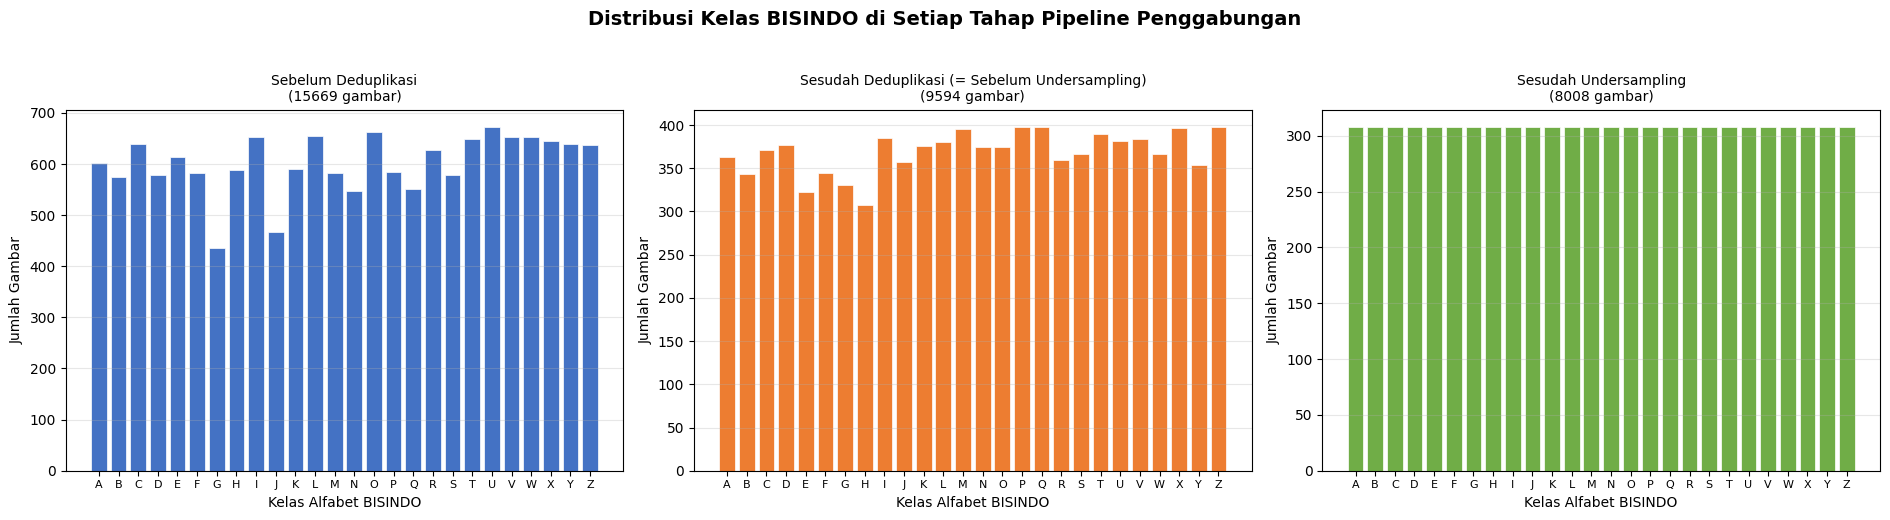

Grafik disimpan: distribusi_tiap_tahap_pipeline.png


In [32]:
# ============================================================
# SEL 14 — Visualisasi Distribusi pada Setiap Tahap Pipeline
# Menampilkan perbandingan distribusi kelas: sebelum deduplikasi,
# sesudah deduplikasi (= sebelum undersampling), dan sesudah
# undersampling.
# ============================================================

def distribusi_per_kelas(items: List[Dict], nc: int = len(CANONICAL_CLASSES)) -> List[int]:
    """Hitung jumlah gambar per kelas dominan dari sebuah list item."""
    counter = Counter(it['dominant_class'] for it in items)
    return [counter.get(i, 0) for i in range(nc)]

tahap = [
    ('Sebelum Deduplikasi', all_items, '#4472C4'),
    ('Sesudah Deduplikasi (= Sebelum Undersampling)', unique_items, '#ED7D31'),
    ('Sesudah Undersampling', balanced_items, '#70AD47'),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle('Distribusi Kelas BISINDO di Setiap Tahap Pipeline Penggabungan', fontsize=14, fontweight='bold', y=1.03)

for ax, (judul, items, warna) in zip(axes, tahap):
    counts = distribusi_per_kelas(items)
    ax.bar(CANONICAL_CLASSES, counts, color=warna, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{judul}\n({sum(counts)} gambar)', fontsize=10)
    ax.set_xlabel('Kelas Alfabet BISINDO')
    ax.set_ylabel('Jumlah Gambar')
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{HOME}/distribusi_tiap_tahap_pipeline.png', dpi=300, bbox_inches='tight')
plt.show()
print('Grafik disimpan: distribusi_tiap_tahap_pipeline.png')


---
## BAGIAN 9 — Stratified Split 80% : 10% : 10%
*(Menjamin proporsi setiap huruf A–Z konsisten di train, valid, dan test; dijalankan pada data hasil dedup + undersampling)*


In [33]:
# ============================================================
# SEL 15 — Stratified Split 80% : 10% : 10% (train : valid : test)
# Dijalankan pada `balanced_items` (hasil dedup + undersampling)
# menggunakan sklearn train_test_split dengan stratify=dominant_class
# sehingga proporsi tiap huruf terjaga sama di ketiga split.
# ============================================================
labels_for_split = [item['dominant_class'] for item in balanced_items]
indices = list(range(len(balanced_items)))

TRAIN_RATIO = SPLIT_RATIO['train']   # 0.80
VALID_RATIO = SPLIT_RATIO['valid']   # 0.10
TEST_RATIO  = SPLIT_RATIO['test']    # 0.10

# Split 1: 80% train vs 20% sisanya (valid+test), stratified
train_idx, temp_idx = train_test_split(
    indices,
    test_size=(VALID_RATIO + TEST_RATIO),
    random_state=SEED,
    stratify=labels_for_split,
)

# Split 2: bagi 20% sisa menjadi valid (10%) dan test (10%), stratified
temp_labels = [labels_for_split[i] for i in temp_idx]
valid_idx, test_idx = train_test_split(
    temp_idx,
    test_size=(TEST_RATIO / (VALID_RATIO + TEST_RATIO)),
    random_state=SEED,
    stratify=temp_labels,
)

print(f'Train : {len(train_idx)} gambar ({len(train_idx)/len(balanced_items)*100:.1f}%)')
print(f'Valid : {len(valid_idx)} gambar ({len(valid_idx)/len(balanced_items)*100:.1f}%)')
print(f'Test  : {len(test_idx)} gambar ({len(test_idx)/len(balanced_items)*100:.1f}%)')
print(f'Total : {len(train_idx) + len(valid_idx) + len(test_idx)} gambar')


Train : 6406 gambar (80.0%)
Valid : 801 gambar (10.0%)
Test  : 801 gambar (10.0%)
Total : 8008 gambar


---
## BAGIAN 10 — Validasi Keseimbangan Kelas Antar Split


VALIDASI #1 — KEHADIRAN KELAS DI SETIAP SPLIT
  A: train= 247 | valid=  31 | test=  30  [OK]
  B: train= 247 | valid=  30 | test=  31  [OK]
  C: train= 246 | valid=  31 | test=  31  [OK]
  D: train= 246 | valid=  31 | test=  31  [OK]
  E: train= 246 | valid=  31 | test=  31  [OK]
  F: train= 247 | valid=  31 | test=  30  [OK]
  G: train= 246 | valid=  31 | test=  31  [OK]
  H: train= 246 | valid=  31 | test=  31  [OK]
  I: train= 247 | valid=  30 | test=  31  [OK]
  J: train= 247 | valid=  30 | test=  31  [OK]
  K: train= 246 | valid=  31 | test=  31  [OK]
  L: train= 247 | valid=  30 | test=  31  [OK]
  M: train= 246 | valid=  31 | test=  31  [OK]
  N: train= 247 | valid=  31 | test=  30  [OK]
  O: train= 246 | valid=  31 | test=  31  [OK]
  P: train= 246 | valid=  31 | test=  31  [OK]
  Q: train= 247 | valid=  30 | test=  31  [OK]
  R: train= 246 | valid=  31 | test=  31  [OK]
  S: train= 246 | valid=  31 | test=  31  [OK]
  T: train= 246 | valid=  31 | test=  31  [OK]
  U: train= 24

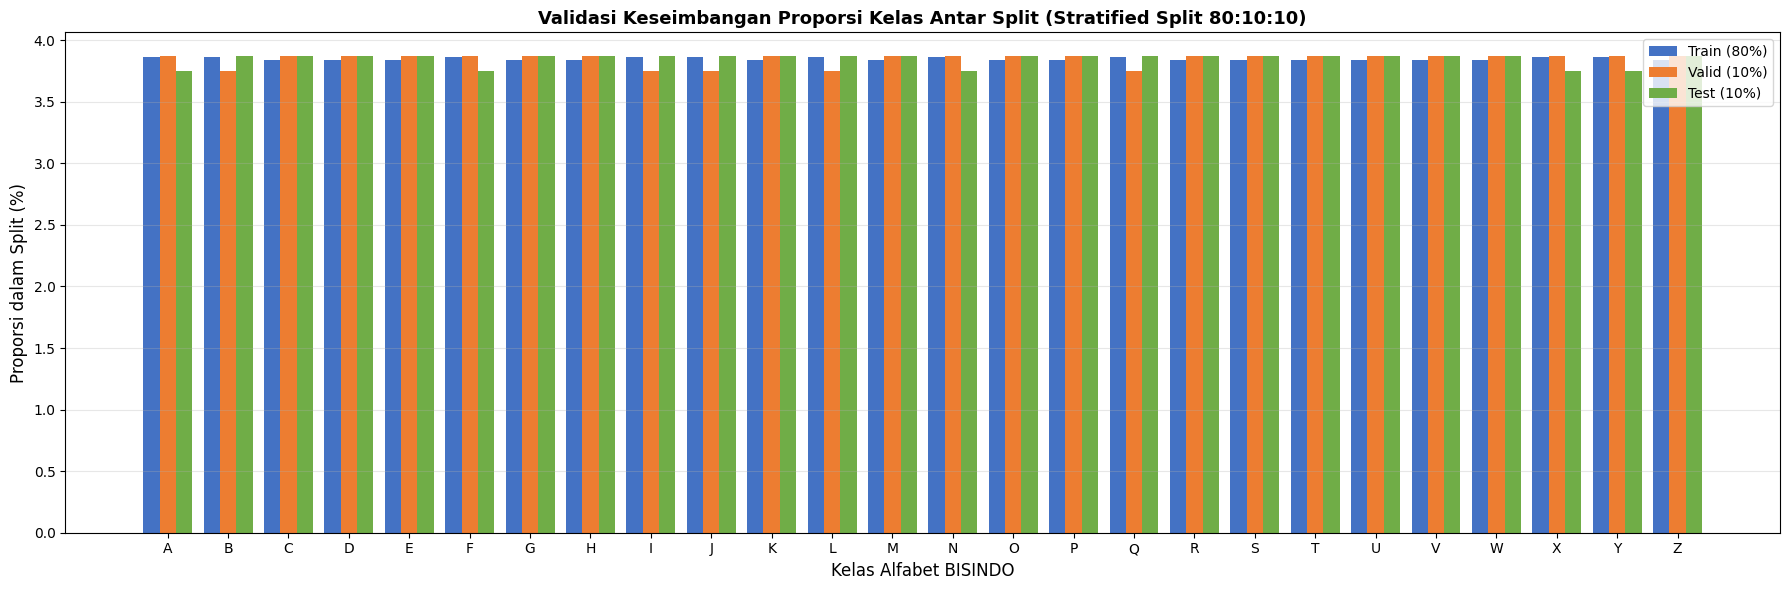

Grafik disimpan: validasi_keseimbangan_split.png

[OK] Validasi lolos. Aman untuk lanjut menyimpan dataset final.


In [34]:
# ============================================================
# SEL 16 — Validasi Split: Kehadiran & Keseimbangan Kelas
# (1) Setiap kelas harus muncul di train, valid, DAN test.
# (2) Proporsi tiap kelas relatif sama di ketiga split.
# Notebook akan berhenti (assert) di akhir sel ini jika validasi #1 gagal.
# ============================================================

def hitung_kelas_per_split(idx_list: List[int]) -> Dict[int, int]:
    """Hitung jumlah gambar per kelas dominan untuk sekumpulan indeks."""
    c = Counter(balanced_items[i]['dominant_class'] for i in idx_list)
    return {cls: c.get(cls, 0) for cls in range(len(CANONICAL_CLASSES))}

count_train = hitung_kelas_per_split(train_idx)
count_valid = hitung_kelas_per_split(valid_idx)
count_test  = hitung_kelas_per_split(test_idx)

print('VALIDASI #1 — KEHADIRAN KELAS DI SETIAP SPLIT')
print('=' * 60)
missing_report = []
for cls in range(len(CANONICAL_CLASSES)):
    huruf = CANONICAL_CLASSES[cls]
    t, v, te = count_train[cls], count_valid[cls], count_test[cls]
    status = 'OK' if (t > 0 and v > 0 and te > 0) else 'HILANG DI SALAH SATU SPLIT'
    if status != 'OK':
        missing_report.append((huruf, t, v, te))
    print(f'  {huruf}: train={t:4d} | valid={v:4d} | test={te:4d}  [{status}]')

if missing_report:
    print(f'\n[!] GAGAL VALIDASI: {len(missing_report)} kelas tidak lengkap di ketiga split.')
    for huruf, t, v, te in missing_report:
        print(f'    {huruf} -> train={t}, valid={v}, test={te}')
else:
    print('\n[OK] Semua 26 kelas (A-Z) hadir di train, valid, DAN test.')

# Validasi #2 — keseimbangan proporsi antar split
total_train = sum(count_train.values())
total_valid = sum(count_valid.values())
total_test  = sum(count_test.values())
MAX_SELISIH_PERSEN = 5.0  # toleransi selisih proporsi antar split (persentase poin)

rows = []
for cls in range(len(CANONICAL_CLASSES)):
    huruf = CANONICAL_CLASSES[cls]
    p_train = count_train[cls] / total_train * 100 if total_train else 0
    p_valid = count_valid[cls] / total_valid * 100 if total_valid else 0
    p_test  = count_test[cls]  / total_test  * 100 if total_test  else 0
    selisih_max = max(p_train, p_valid, p_test) - min(p_train, p_valid, p_test)
    rows.append({
        'Kelas': huruf,
        '% Train': round(p_train, 2),
        '% Valid': round(p_valid, 2),
        '% Test':  round(p_test, 2),
        'Selisih Maks (pp)': round(selisih_max, 2),
        'Seimbang': 'Ya' if selisih_max <= MAX_SELISIH_PERSEN else 'TIDAK',
    })

df_validasi = pd.DataFrame(rows)
print(f'\nVALIDASI #2 — KESEIMBANGAN PROPORSI KELAS ANTAR SPLIT (toleransi {MAX_SELISIH_PERSEN} pp)')
print('=' * 70)
print(df_validasi.to_string(index=False))

n_tidak_seimbang = (df_validasi['Seimbang'] == 'TIDAK').sum()
if n_tidak_seimbang:
    print(f'\n[!] {n_tidak_seimbang} kelas melebihi toleransi selisih proporsi (wajar untuk kelas berdata sangat sedikit).')
else:
    print('\n[OK] Seluruh kelas seimbang antar split (dalam toleransi).')

df_validasi.to_csv(f'{HOME}/validasi_keseimbangan_split.csv', index=False)

# Visualisasi grouped bar chart
x = np.arange(len(CANONICAL_CLASSES))
width = 0.27
fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(x - width, df_validasi['% Train'], width, label='Train (80%)', color='#4472C4')
ax.bar(x,          df_validasi['% Valid'], width, label='Valid (10%)', color='#ED7D31')
ax.bar(x + width,  df_validasi['% Test'],  width, label='Test (10%)',  color='#70AD47')
ax.set_xlabel('Kelas Alfabet BISINDO', fontsize=12)
ax.set_ylabel('Proporsi dalam Split (%)', fontsize=12)
ax.set_title('Validasi Keseimbangan Proporsi Kelas Antar Split (Stratified Split 80:10:10)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CANONICAL_CLASSES)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{HOME}/validasi_keseimbangan_split.png', dpi=300, bbox_inches='tight')
plt.show()
print('Grafik disimpan: validasi_keseimbangan_split.png')

# Hentikan proses jika validasi #1 gagal total (kelas hilang) — mencegah lanjut ke training dengan data cacat
assert len(missing_report) == 0, 'STOP: Ada kelas yang hilang di salah satu split. Perbaiki dataset/mapping sebelum lanjut ke SEL 17.'
print('\n[OK] Validasi lolos. Aman untuk lanjut menyimpan dataset final.')


---
## BAGIAN 11 — Simpan Dataset Final ke Disk


In [35]:
# ============================================================
# SEL 17 — Tulis Dataset Final ke Disk (dataset_final/)
# Nama file diberi prefix nama dataset asal untuk menghindari
# bentrok nama antar dataset sumber yang berbeda.
# ============================================================

def tulis_split(nama_split: str, idx_list: List[int]) -> None:
    """Salin gambar & tulis label hasil gabungan untuk satu split ke MERGED_DIR."""
    img_out = f'{MERGED_DIR}/{nama_split}/images'
    lbl_out = f'{MERGED_DIR}/{nama_split}/labels'
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)
    for i in tqdm(idx_list, desc=f'Menulis {nama_split}'):
        item = balanced_items[i]
        base = f"{item['dataset']}_{os.path.splitext(os.path.basename(item['img_path']))[0]}"
        ext = os.path.splitext(item['img_path'])[1]
        try:
            shutil.copy2(item['img_path'], f'{img_out}/{base}{ext}')
            with open(f'{lbl_out}/{base}.txt', 'w') as f:
                f.write('\n'.join(item['label_lines']))
        except Exception as exc:
            logger.warning('Gagal menyalin %s: %s', item['img_path'], exc)

tulis_split('train', train_idx)
tulis_split('valid', valid_idx)
tulis_split('test',  test_idx)

print('\nSelesai menulis dataset final ke:', MERGED_DIR)


Menulis train:   0%|          | 0/6406 [00:00<?, ?it/s]

Menulis valid:   0%|          | 0/801 [00:00<?, ?it/s]

Menulis test:   0%|          | 0/801 [00:00<?, ?it/s]


Selesai menulis dataset final ke: /content/dataset_final


In [36]:
# ============================================================
# SEL 18 — Tulis data.yaml untuk Dataset Final
# ============================================================
merged_yaml = {
    'train': f'{MERGED_DIR}/train/images',
    'val':   f'{MERGED_DIR}/valid/images',
    'test':  f'{MERGED_DIR}/test/images',
    'nc':    len(CANONICAL_CLASSES),
    'names': CANONICAL_CLASSES,
}

MERGED_YAML_PATH = f'{MERGED_DIR}/data.yaml'
with open(MERGED_YAML_PATH, 'w') as f:
    yaml.dump(merged_yaml, f, sort_keys=False, allow_unicode=True)

print('data.yaml dataset final tersimpan di:', MERGED_YAML_PATH)
print(json.dumps(merged_yaml, indent=2))


data.yaml dataset final tersimpan di: /content/dataset_final/data.yaml
{
  "train": "/content/dataset_final/train/images",
  "val": "/content/dataset_final/valid/images",
  "test": "/content/dataset_final/test/images",
  "nc": 26,
  "names": [
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "J",
    "K",
    "L",
    "M",
    "N",
    "O",
    "P",
    "Q",
    "R",
    "S",
    "T",
    "U",
    "V",
    "W",
    "X",
    "Y",
    "Z"
  ]
}


---
## BAGIAN 12 — Ringkasan Pipeline Penggabungan Dataset


In [37]:
# ============================================================
# SEL 19 — Ringkasan Akhir Pipeline Penggabungan Dataset
# ============================================================
ringkasan = [
    ['Jumlah dataset sumber terdaftar', f'{len(SOURCE_DATASETS)}'],
    ['Jumlah dataset sumber berhasil diunduh', f'{len(downloaded)}'],
    ['Jumlah gambar sebelum deduplikasi', f'{len(all_items)}'],
    ['Jumlah gambar sesudah deduplikasi', f'{len(unique_items)}'],
    ['Jumlah gambar dihapus sebagai duplikat', f'{len(all_items) - len(unique_items)}'],
    ['Jumlah gambar sebelum undersampling', f'{len(unique_items)}'],
    ['Jumlah gambar sesudah undersampling', f'{len(balanced_items)}'],
    ['Jumlah minimum gambar per kelas', f'{min_count}'],
    ['Jumlah kelas', f'{len(CANONICAL_CLASSES)} (A-Z)'],
    ['Jumlah data Train (80%)', f'{len(train_idx)}'],
    ['Jumlah data Valid (10%)', f'{len(valid_idx)}'],
    ['Jumlah data Test (10%)', f'{len(test_idx)}'],
    ['Total dataset final', f'{len(train_idx) + len(valid_idx) + len(test_idx)}'],
    ['Direktori dataset final', MERGED_DIR],
    ['File konfigurasi', MERGED_YAML_PATH],
]

df_ringkasan = pd.DataFrame(ringkasan, columns=['Parameter', 'Nilai'])
print('RINGKASAN PIPELINE PENGGABUNGAN DATASET BISINDO')
print('=' * 65)
print(df_ringkasan.to_string(index=False))

print('\nRincian sumber dataset yang digabung:')
for src in downloaded:
    print(f"  - {src['name']}: {src['workspace']}/{src['project']} (v{src['version']})")

df_ringkasan.to_csv(f'{HOME}/ringkasan_pipeline_dataset.csv', index=False)
print(f'\nTabel disimpan: {HOME}/ringkasan_pipeline_dataset.csv')
print('\n[!] Gunakan angka-angka di atas untuk merevisi Bab I (Batasan Masalah)')
print('    dan Bab III (subbab Dataset).')


RINGKASAN PIPELINE PENGGABUNGAN DATASET BISINDO
                             Parameter                            Nilai
       Jumlah dataset sumber terdaftar                               10
Jumlah dataset sumber berhasil diunduh                               10
     Jumlah gambar sebelum deduplikasi                            15669
     Jumlah gambar sesudah deduplikasi                             9594
Jumlah gambar dihapus sebagai duplikat                             6075
   Jumlah gambar sebelum undersampling                             9594
   Jumlah gambar sesudah undersampling                             8008
       Jumlah minimum gambar per kelas                              308
                          Jumlah kelas                         26 (A-Z)
               Jumlah data Train (80%)                             6406
               Jumlah data Valid (10%)                              801
                Jumlah data Test (10%)                              801
                

---
## BAGIAN 13 — Verifikasi & Analisis Dataset Final untuk Training


In [38]:
# ============================================================
# SEL 20 — Verifikasi struktur dataset final & distribusi per split
# Membaca ulang dataset_final/ dari disk (bukan dari memori) sebagai
# pengecekan independen sebelum training dimulai.
# ============================================================
DATA_YAML = MERGED_YAML_PATH
with open(DATA_YAML) as f:
    data_info = yaml.safe_load(f)

CLASS_NAMES = data_info.get('names', CANONICAL_CLASSES)
NC = data_info.get('nc', len(CANONICAL_CLASSES))

print('=' * 55)
print('INFORMASI DATASET BISINDO (GABUNGAN)')
print('=' * 55)
print(f'Jumlah kelas : {NC}')
print(f'Nama kelas   : {CLASS_NAMES}')
print()

total = 0
split_counts = {}
for split in ['train', 'valid', 'test']:
    img_path = f'{MERGED_DIR}/{split}/images'
    lbl_path = f'{MERGED_DIR}/{split}/labels'
    if os.path.exists(img_path):
        n_img = len([f for f in os.listdir(img_path) if f.endswith(('.jpg','.jpeg','.png'))])
        n_lbl = len([f for f in os.listdir(lbl_path) if f.endswith('.txt')]) if os.path.exists(lbl_path) else 0
        split_counts[split] = n_img
        total += n_img
        print(f'{split.capitalize():10s}: {n_img:4d} gambar | {n_lbl:4d} label')

print(f'{"TOTAL":10s}: {total:4d} gambar')
print()
for split, n in split_counts.items():
    print(f'Rasio {split:6s}: {n/total*100:.1f}%')

print('\nPath data.yaml:', DATA_YAML)


INFORMASI DATASET BISINDO (GABUNGAN)
Jumlah kelas : 26
Nama kelas   : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Train     : 6406 gambar | 6406 label
Valid     :  801 gambar |  801 label
Test      :  801 gambar |  801 label
TOTAL     : 8008 gambar

Rasio train : 80.0%
Rasio valid : 10.0%
Rasio test  : 10.0%

Path data.yaml: /content/dataset_final/data.yaml


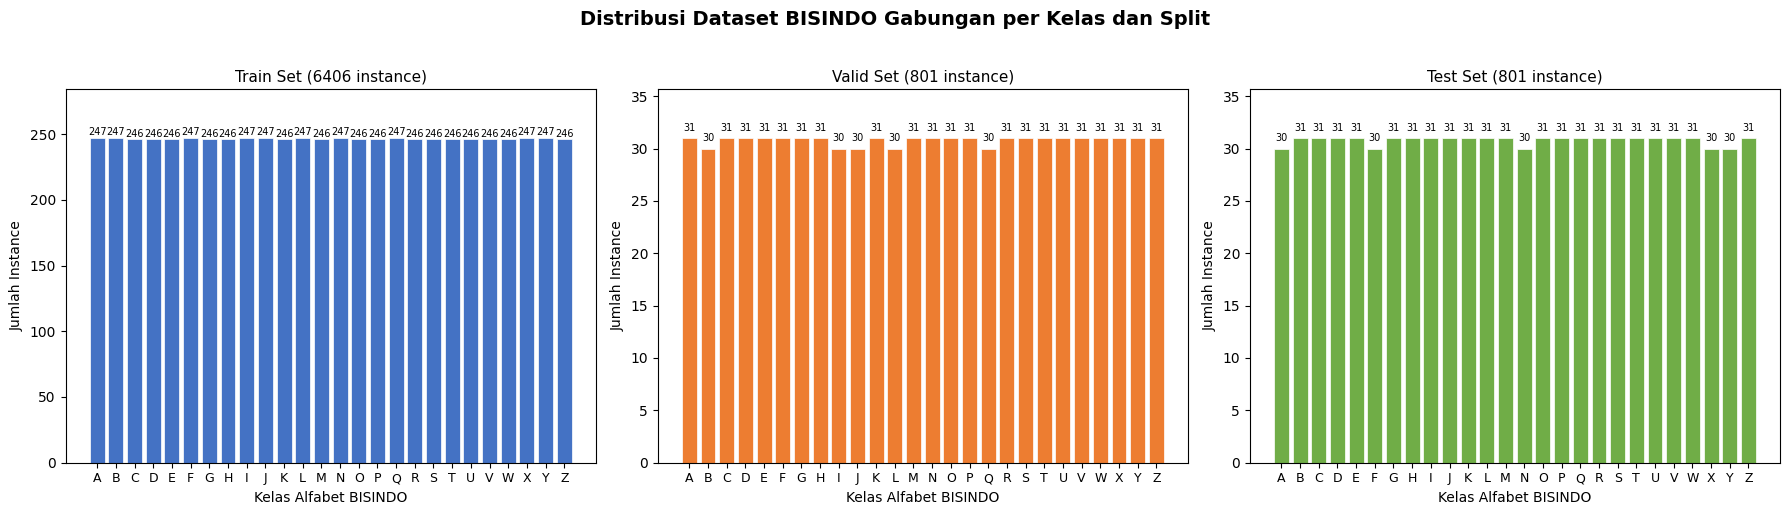

Grafik disimpan: distribusi_dataset_bisindo.png


In [39]:
# ============================================================
# SEL 21 — Visualisasi distribusi jumlah gambar per kelas (dataset final)
# ============================================================

def hitung_distribusi(label_dir, nc=26):
    counter = Counter()
    if not os.path.exists(label_dir):
        return counter
    for lf in os.listdir(label_dir):
        if not lf.endswith('.txt'):
            continue
        with open(os.path.join(label_dir, lf)) as f:
            for line in f:
                line = line.strip()
                if line:
                    cls_id = int(line.split()[0])
                    counter[cls_id] += 1
    return counter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Dataset BISINDO Gabungan per Kelas dan Split', fontsize=14, fontweight='bold', y=1.02)

colors = {'train': '#4472C4', 'valid': '#ED7D31', 'test': '#70AD47'}
for ax, split in zip(axes, ['train', 'valid', 'test']):
    lbl_dir = f'{MERGED_DIR}/{split}/labels'
    dist = hitung_distribusi(lbl_dir, NC)
    counts = [dist.get(i, 0) for i in range(NC)]
    bars = ax.bar(CLASS_NAMES, counts, color=colors[split], edgecolor='white', linewidth=0.5)
    ax.set_title(f'{split.capitalize()} Set ({sum(counts)} instance)', fontsize=11)
    ax.set_xlabel('Kelas Alfabet BISINDO')
    ax.set_ylabel('Jumlah Instance')
    ax.set_ylim(0, max(counts) * 1.15 if counts else 1)
    ax.tick_params(axis='x', labelsize=9)
    for bar, val in zip(bars, counts):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(val), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f'{HOME}/distribusi_dataset_bisindo.png', dpi=300, bbox_inches='tight')
plt.show()
print('Grafik disimpan: distribusi_dataset_bisindo.png')


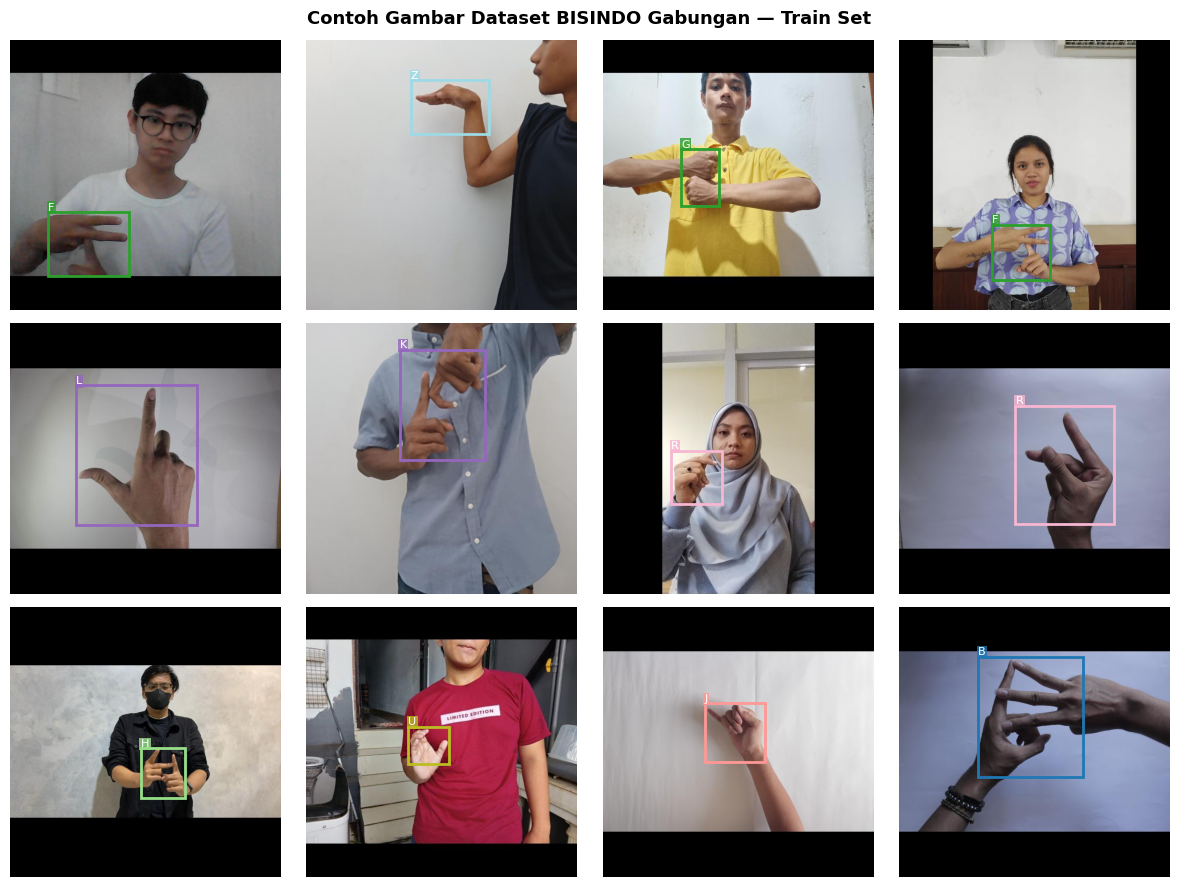

Gambar disimpan: contoh_dataset_train.png


In [40]:
# ============================================================
# SEL 22 — Tampilkan contoh gambar beserta anotasi bounding box
# ============================================================
import cv2
from IPython.display import Image as IPyImage, display
import matplotlib.patches as patches

def tampilkan_contoh_dataset(split='train', n=12, cols=4):
    img_dir = f'{MERGED_DIR}/{split}/images'
    lbl_dir = f'{MERGED_DIR}/{split}/labels'
    img_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg','.jpeg','.png'))]
    random.seed(SEED)
    samples = random.sample(img_files, min(n, len(img_files)))
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    COLORS = plt.cm.get_cmap('tab20', NC)
    for ax, fname in zip(axes, samples):
        img_path = os.path.join(img_dir, fname)
        lbl_path = os.path.join(lbl_dir, fname.rsplit('.', 1)[0] + '.txt')
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        ax.imshow(img)
        ax.axis('off')
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5: continue
                    cls_id, xc, yc, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    x1 = (xc - bw/2) * w
                    y1 = (yc - bh/2) * h
                    rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                             linewidth=2, edgecolor=COLORS(cls_id), facecolor='none')
                    ax.add_patch(rect)
                    lbl = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
                    ax.text(x1, y1 - 3, lbl, color='white', fontsize=8,
                            bbox=dict(facecolor=COLORS(cls_id), alpha=0.8, pad=1, edgecolor='none'))
    for ax in axes[len(samples):]:
        ax.axis('off')
    fig.suptitle(f'Contoh Gambar Dataset BISINDO Gabungan — {split.capitalize()} Set', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{HOME}/contoh_dataset_{split}.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Gambar disimpan: contoh_dataset_{split}.png')

tampilkan_contoh_dataset(split='train', n=12, cols=4)


---
## BAGIAN 14 — Konfigurasi Bersama untuk Training Nano & Small


In [41]:
# ============================================================
# SEL 23 — Hyperparameter Training (Nano & Small)
# ============================================================
CONF_THRESHOLD = 0.90
IOU_THRESHOLD  = 0.50

TRAIN_HYPERPARAMS: Dict = dict(
    data          = MERGED_YAML_PATH,
    epochs        = 50,
    imgsz         = 640,
    batch         = 16,
    optimizer     = 'AdamW',
    lr0           = 0.0003,
    weight_decay  = 0.0005,
    patience      = 10,
    seed          = SEED,
    deterministic = True,
    plots         = True,
    exist_ok      = True,
    # --- Seluruh augmentasi dinonaktifkan ---
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    degrees=0.0, translate=0.0, scale=0.0, shear=0.0, perspective=0.0,
    flipud=0.0, fliplr=0.0,
    mosaic=0.0, mixup=0.0, copy_paste=0.0, erasing=0.0,
)

print('HYPERPARAMETER TRAINING (SAMA UNTUK NANO & SMALL)')
print('=' * 50)
for k, v in TRAIN_HYPERPARAMS.items():
    print(f'  {k:<14}: {v}')
print(f'\nConfidence threshold (evaluasi & real-time): {CONF_THRESHOLD}')
print(f'IoU threshold                               : {IOU_THRESHOLD}')


HYPERPARAMETER TRAINING (SAMA UNTUK NANO & SMALL)
  data          : /content/dataset_final/data.yaml
  epochs        : 50
  imgsz         : 640
  batch         : 16
  optimizer     : AdamW
  lr0           : 0.0003
  weight_decay  : 0.0005
  patience      : 10
  seed          : 42
  deterministic : True
  plots         : True
  exist_ok      : True
  hsv_h         : 0.0
  hsv_s         : 0.0
  hsv_v         : 0.0
  degrees       : 0.0
  translate     : 0.0
  scale         : 0.0
  shear         : 0.0
  perspective   : 0.0
  flipud        : 0.0
  fliplr        : 0.0
  mosaic        : 0.0
  mixup         : 0.0
  copy_paste    : 0.0
  erasing       : 0.0

Confidence threshold (evaluasi & real-time): 0.9
IoU threshold                               : 0.5


---
## BAGIAN 15 — Training YOLOv11 Nano


In [42]:
# ============================================================
# SEL 24 — Training YOLOv11 Nano (yolo11n.pt)
# Hasil disimpan di runs/detect/YOLOv11_Nano/
# ============================================================
from ultralytics import YOLO

os.chdir(HOME)
model_nano = YOLO('yolo11n.pt')
model_nano.train(name='YOLOv11_Nano', **TRAIN_HYPERPARAMS)

TRAIN_DIR_NANO = f'{HOME}/runs/detect/YOLOv11_Nano'
BEST_NANO_PATH = f'{TRAIN_DIR_NANO}/weights/best.pt'
print(f'\nTraining YOLOv11 Nano selesai.')
print(f'Folder hasil : {TRAIN_DIR_NANO}')
print(f'best.pt ada  : {os.path.exists(BEST_NANO_PATH)}')


100%|██████████| 5.35M/5.35M [00:00<00:00, 121MB/s]

New https://pypi.org/project/ultralytics/8.4.115 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)


engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/dataset_final/data.yaml, epochs=50, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=YOLOv11_Nano, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format=torchscript, keras=False, optimize=Fal

100%|██████████| 755k/755k [00:00<00:00, 27.0MB/s]


Overriding model.yaml nc=80 with nc=26

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytic

...

      27/50      2.43G     0.2435     0.2061     0.7795          6        640: 100%|██████████| 401/401 [01:12<00:00,  5.52it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:05<00:00,  4.49it/s]

                   all        801        801      0.974       0.95      0.981      0.767
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 17, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



27 epochs completed in 0.613 hours.
Optimizer stripped from runs/detect/YOLOv11_Nano/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/YOLOv11_Nano/weights/best.pt, 5.5MB

Validating runs/detect/YOLOv11_Nano/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 238 layers, 2,587,222 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:07<00:00,  3.44it/s]


                   all        801        801      0.971       0.95      0.978      0.771
                     A         31         31      0.993          1      0.995      0.788
                     B         30         30      0.955      0.967       0.96      0.767
                     C         31         31          1      0.949      0.995      0.735
                     D         31         31      0.929      0.968      0.942      0.773
                     E         31         31          1      0.981      0.995      0.785
                     F         31         31      0.973      0.968      0.994      0.789
                     G         31         31          1      0.914      0.994      0.737
                     H         31         31      0.988          1      0.995      0.793
                     I         30         30          1      0.899      0.968      0.784
                     J         30         30      0.983      0.933      0.962      0.759
                     

---
## BAGIAN 16 — Training YOLOv11 Small


In [43]:
# ============================================================
# SEL 25 — Training YOLOv11 Small (yolo11s.pt)
# Hasil disimpan di runs/detect/YOLOv11_Small/
# ============================================================
os.chdir(HOME)
model_small = YOLO('yolo11s.pt')
model_small.train(name='YOLOv11_Small', **TRAIN_HYPERPARAMS)

TRAIN_DIR_SMALL = f'{HOME}/runs/detect/YOLOv11_Small'
BEST_SMALL_PATH = f'{TRAIN_DIR_SMALL}/weights/best.pt'
print(f'\nTraining YOLOv11 Small selesai.')
print(f'Folder hasil : {TRAIN_DIR_SMALL}')
print(f'best.pt ada  : {os.path.exists(BEST_SMALL_PATH)}')


100%|██████████| 18.4M/18.4M [00:00<00:00, 87.9MB/s]


New https://pypi.org/project/ultralytics/8.4.115 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/dataset_final/data.yaml, epochs=50, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=YOLOv11_Small, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=Fal

train: Scanning /content/dataset_final/train/labels.cache... 6406 images, 0 backgrounds, 0 corrupt: 100%|██████████| 6406/6406 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/dataset_final/valid/labels.cache... 801 images, 0 backgrounds, 0 corrupt: 100%|██████████| 801/801 [00:00<?, ?it/s]


...

      50/50      4.59G    0.06145    0.07498     0.7537          6        640: 100%|██████████| 401/401 [01:57<00:00,  3.40it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:08<00:00,  3.14it/s]

                   all        801        801      0.985      0.967      0.987       0.81



50 epochs completed in 1.754 hours.
Optimizer stripped from runs/detect/YOLOv11_Small/weights/last.pt, 19.2MB
Optimizer stripped from runs/detect/YOLOv11_Small/weights/best.pt, 19.2MB

Validating runs/detect/YOLOv11_Small/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,422,862 parameters, 0 gradients, 21.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:10<00:00,  2.54it/s]


                   all        801        801      0.985      0.967      0.987      0.809
                     A         31         31      0.994          1      0.995      0.818
                     B         30         30      0.961      0.967      0.966      0.749
                     C         31         31      0.993          1      0.995      0.772
                     D         31         31      0.994          1      0.995      0.796
                     E         31         31          1      0.945      0.995      0.797
                     F         31         31      0.994          1      0.995       0.85
                     G         31         31       0.99      0.968      0.978      0.762
                     H         31         31      0.995          1      0.995      0.852
                     I         30         30      0.963          1      0.994      0.837
                     J         30         30      0.998        0.9       0.98      0.814
                     

---
## BAGIAN 17 — Validation & Test YOLOv11 Nano


In [44]:
# ============================================================
# SEL 26 — Validation & Test Set — YOLOv11 Nano
# ============================================================
model_nano_eval = YOLO(BEST_NANO_PATH)

print('='*70)
print('VALIDATION SET — YOLOv11 NANO')
print('='*70)
val_nano = model_nano_eval.val(
    data=DATA_YAML,
    split='val',
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    verbose=True,
)

test_img_dir = f'{MERGED_DIR}/test/images'
split_eval = 'test' if os.path.exists(test_img_dir) else 'val'

print('\n' + '='*70)
print(f'{split_eval.upper()} SET — YOLOv11 NANO')
print('='*70)
if split_eval == 'test':
    test_nano = model_nano_eval.val(
        data=DATA_YAML,
        split='test',
        conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD,
        verbose=True,
    )
else:
    print('[!] Test set tidak tersedia — menggunakan validation set sebagai evaluasi final.')
    test_nano = val_nano


VALIDATION SET — YOLOv11 NANO
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 238 layers, 2,587,222 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning /content/dataset_final/valid/labels.cache... 801 images, 0 backgrounds, 0 corrupt: 100%|██████████| 801/801 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:09<00:00,  5.25it/s]


                   all        801        801      0.989      0.828      0.908      0.745
                     A         31         31          1      0.903      0.952      0.771
                     B         30         30      0.967      0.967      0.973      0.793
                     C         31         31          1      0.839      0.919      0.708
                     D         31         31      0.964      0.871      0.905      0.759
                     E         31         31          1      0.839      0.919      0.756
                     F         31         31          1      0.903      0.952      0.779
                     G         31         31          1      0.871      0.935      0.733
                     H         31         31          1      0.935      0.968      0.796
                     I         30         30          1      0.767      0.883      0.763
                     J         30         30          1      0.733      0.867      0.744
                     

val: Scanning /content/dataset_final/test/labels... 801 images, 0 backgrounds, 0 corrupt: 100%|██████████| 801/801 [00:01<00:00, 765.33it/s]

val: New cache created: /content/dataset_final/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:09<00:00,  5.51it/s]


                   all        801        801      0.983       0.83      0.908      0.732
                     A         30         30          1      0.933      0.967      0.777
                     B         31         31          1      0.903      0.952      0.772
                     C         31         31          1      0.903      0.952      0.739
                     D         31         31          1      0.871      0.935      0.758
                     E         31         31          1      0.903      0.952      0.741
                     F         30         30          1        0.9       0.95      0.698
                     G         31         31          1      0.935      0.968        0.8
                     H         31         31          1      0.935      0.968      0.843
                     I         31         31          1       0.71      0.855      0.684
                     J         31         31          1      0.806      0.903      0.756
                     

---
## BAGIAN 18 — Validation & Test YOLOv11 Small


In [45]:
# ============================================================
# SEL 27 — Validation & Test Set — YOLOv11 Small
# ============================================================
model_small_eval = YOLO(BEST_SMALL_PATH)

print('='*70)
print('VALIDATION SET — YOLOv11 SMALL')
print('='*70)
val_small = model_small_eval.val(
    data=DATA_YAML,
    split='val',
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    verbose=True,
)

print('\n' + '='*70)
print(f'{split_eval.upper()} SET — YOLOv11 SMALL')
print('='*70)
if split_eval == 'test':
    test_small = model_small_eval.val(
        data=DATA_YAML,
        split='test',
        conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD,
        verbose=True,
    )
else:
    print('[!] Test set tidak tersedia — menggunakan validation set sebagai evaluasi final.')
    test_small = val_small


VALIDATION SET — YOLOv11 SMALL
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,422,862 parameters, 0 gradients, 21.4 GFLOPs


val: Scanning /content/dataset_final/valid/labels.cache... 801 images, 0 backgrounds, 0 corrupt: 100%|██████████| 801/801 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:14<00:00,  3.40it/s]


                   all        801        801      0.994      0.954      0.972      0.805
                     A         31         31          1          1      0.995       0.82
                     B         30         30      0.967      0.967      0.969      0.751
                     C         31         31          1          1      0.995      0.782
                     D         31         31          1          1      0.995      0.799
                     E         31         31          1      0.903      0.952      0.777
                     F         31         31          1          1      0.995      0.848
                     G         31         31          1      0.968      0.984      0.769
                     H         31         31          1          1      0.995      0.855
                     I         30         30          1      0.967      0.983      0.843
                     J         30         30          1      0.867      0.933      0.806
                     

val: Scanning /content/dataset_final/test/labels.cache... 801 images, 0 backgrounds, 0 corrupt: 100%|██████████| 801/801 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:14<00:00,  3.60it/s]


                   all        801        801      0.988      0.946      0.968      0.801
                     A         30         30          1      0.967      0.983      0.826
                     B         31         31          1      0.968      0.984      0.825
                     C         31         31          1      0.968      0.984      0.828
                     D         31         31          1          1      0.995      0.838
                     E         31         31          1      0.968      0.984      0.766
                     F         30         30          1      0.967      0.983       0.75
                     G         31         31          1          1      0.995      0.852
                     H         31         31          1          1      0.995      0.868
                     I         31         31          1      0.968      0.984      0.786
                     J         31         31          1      0.968      0.984      0.831
                     

---
## BAGIAN 19 — Confusion Matrix & Results — YOLOv11 Nano



--- Confusion Matrix (Normalized) — Nano ---


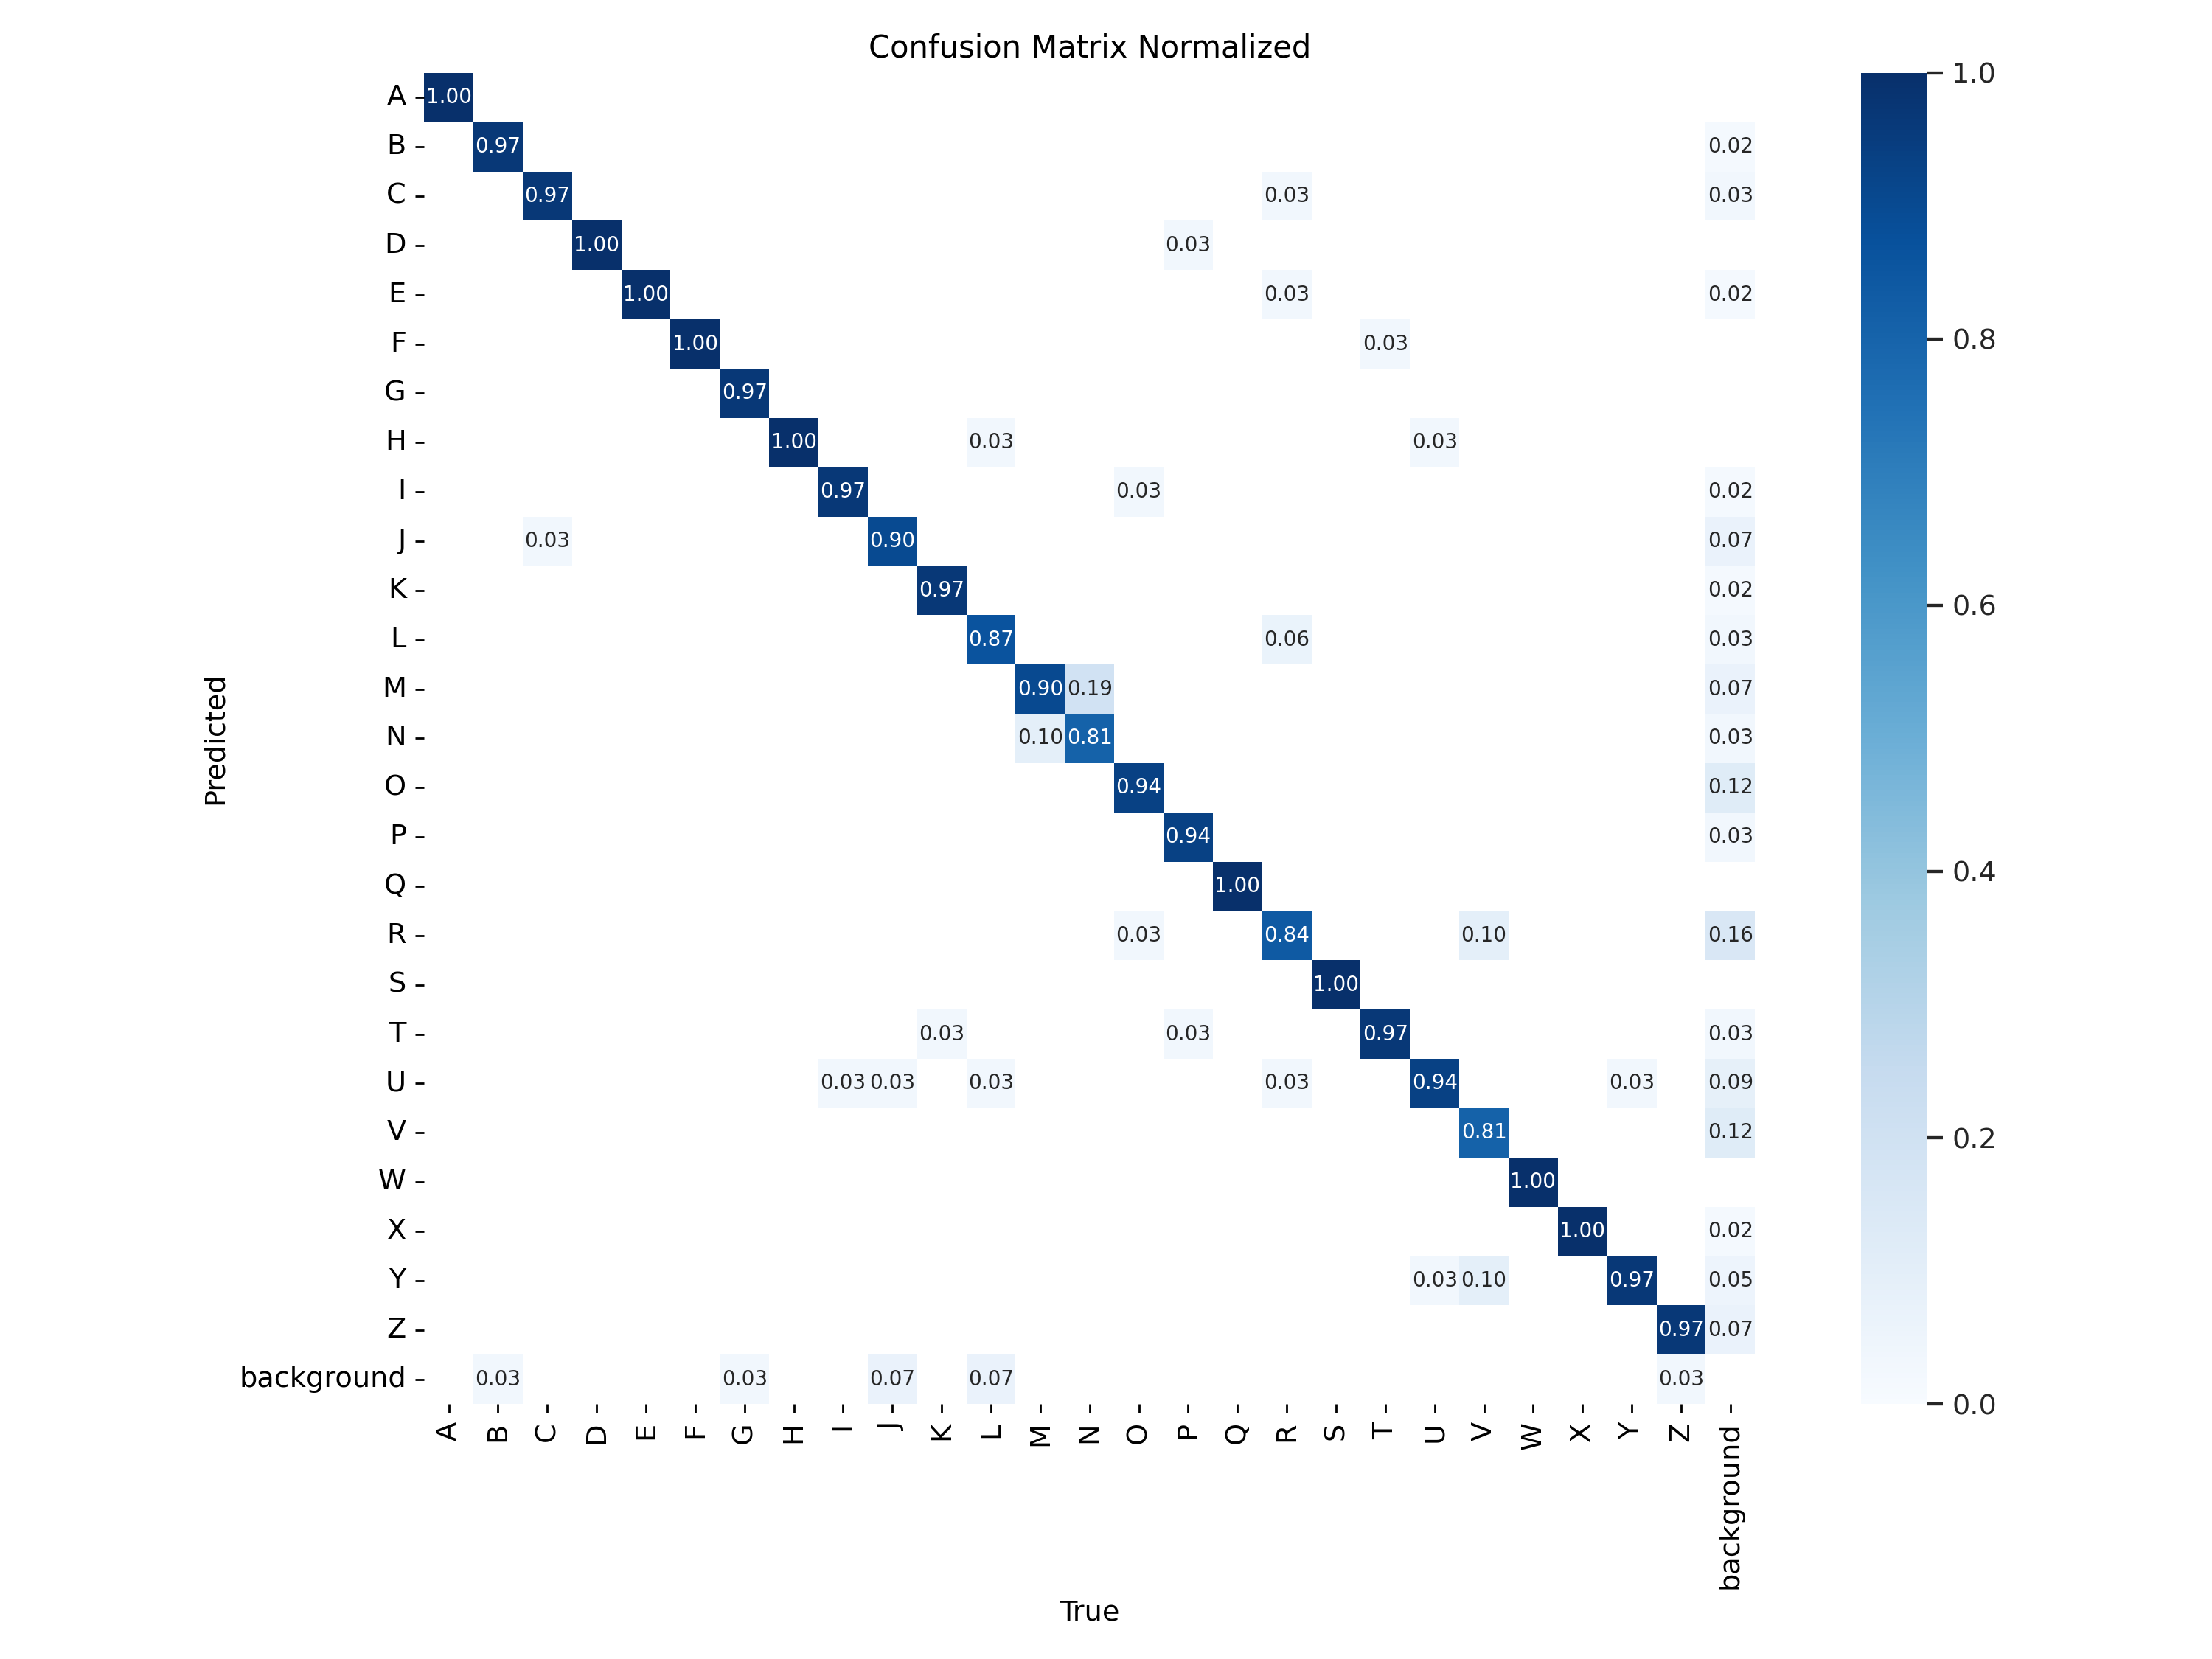


--- Results — Nano ---


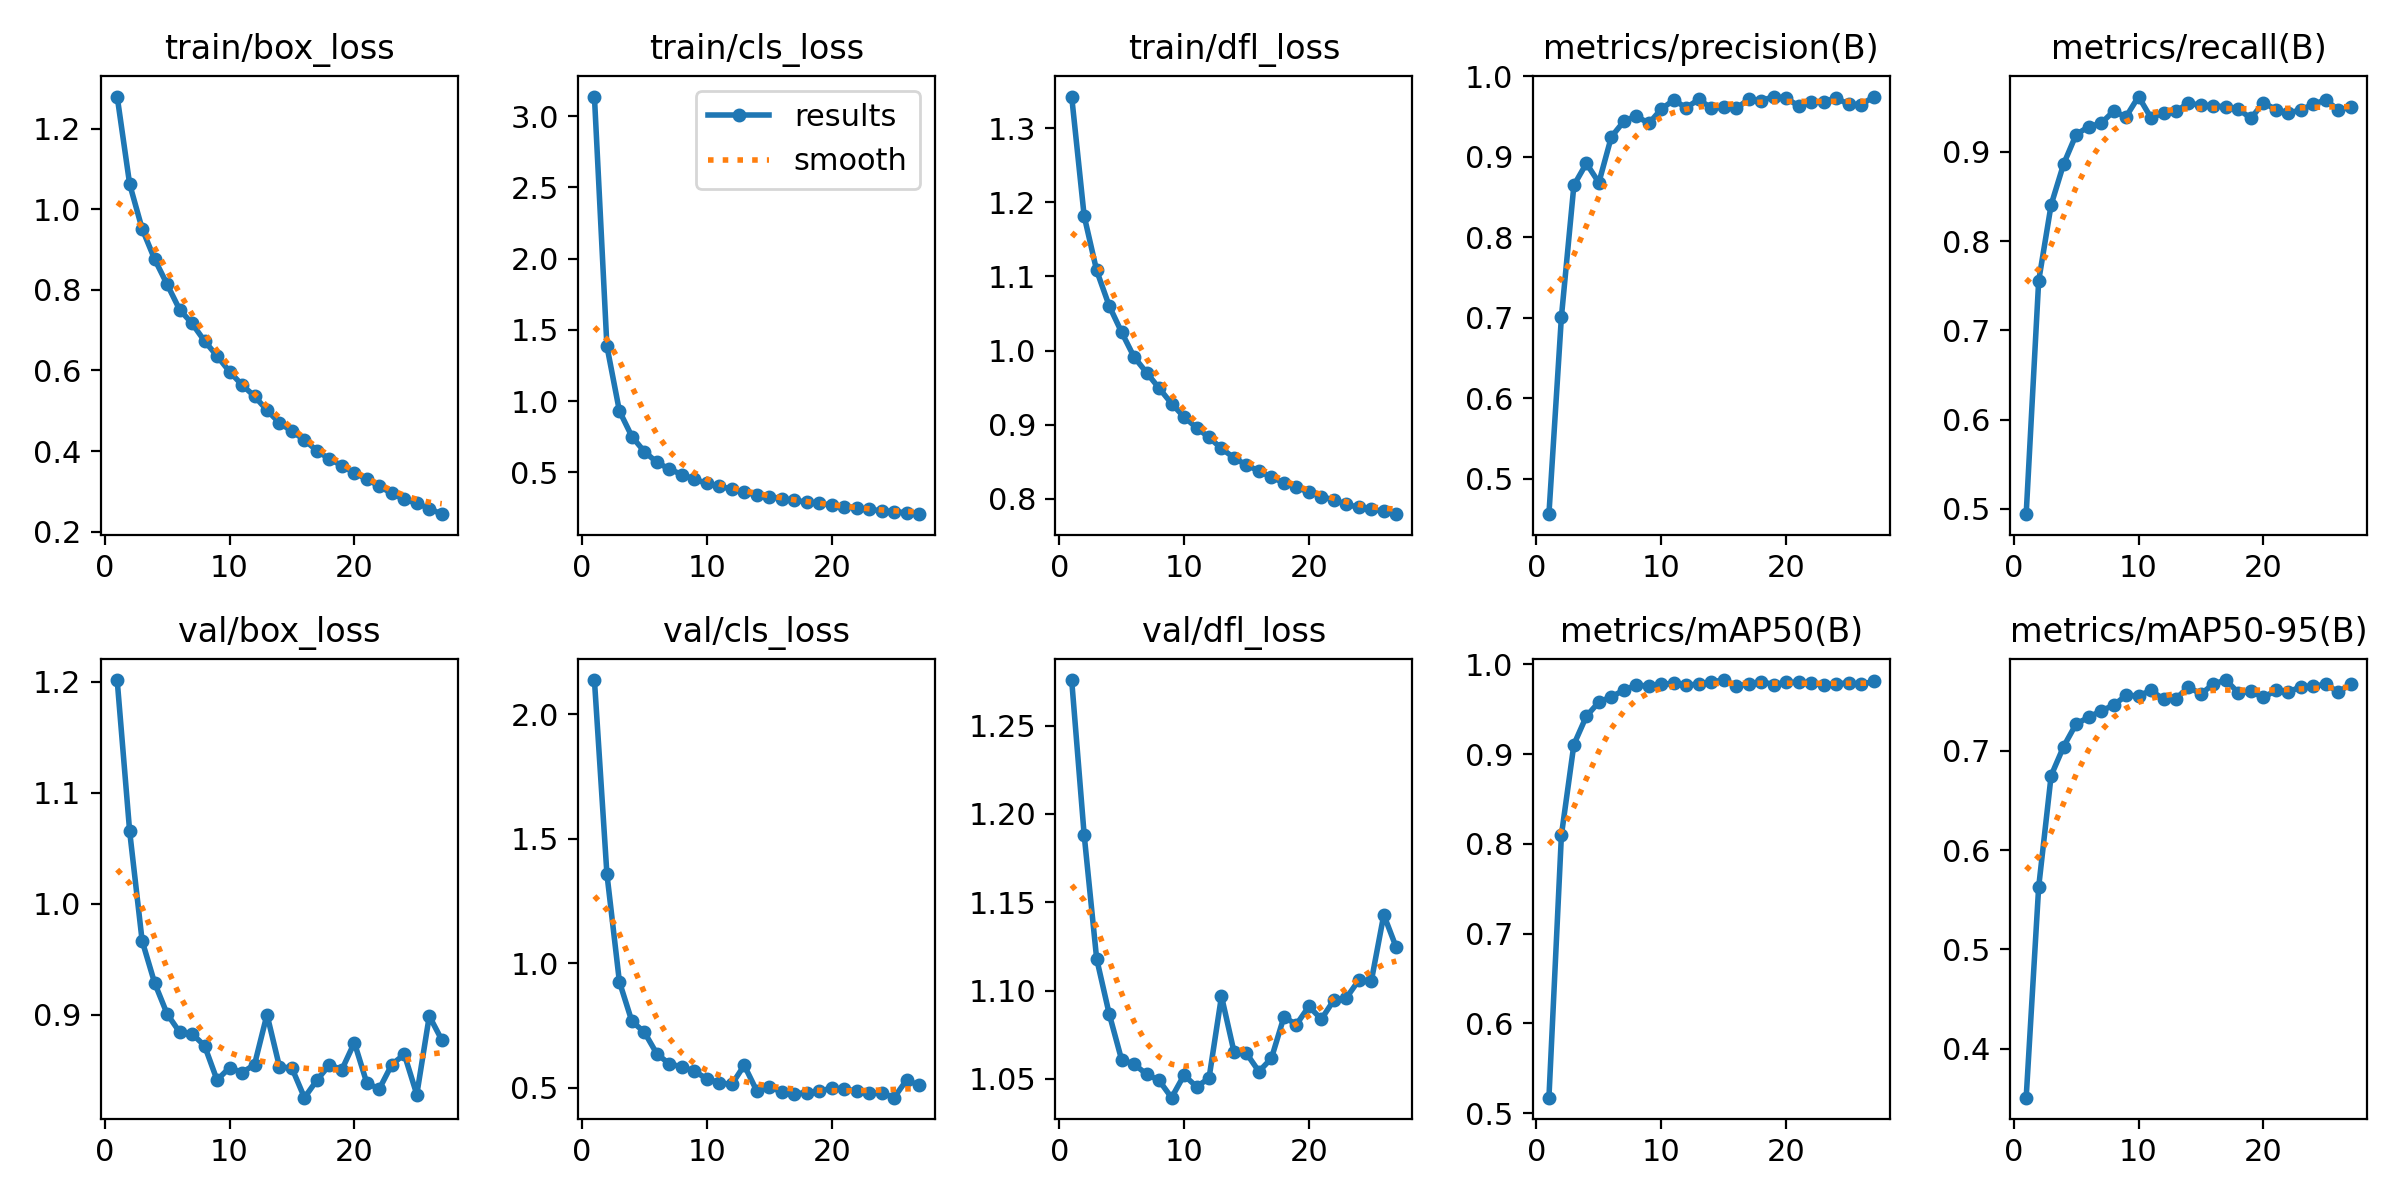

In [46]:
# ============================================================
# SEL 28 — Visualisasi Hasil Training — YOLOv11 Nano
# confusion_matrix_normalized.png, results.png
# ============================================================
from IPython.display import Image as IPyImage, display

gambar_nano = [
    ('confusion_matrix_normalized.png', 'Confusion Matrix (Normalized) — Nano'),
    ('results.png',                     'Results — Nano'),
]

for fname, judul in gambar_nano:
    fpath = f'{TRAIN_DIR_NANO}/{fname}'
    if os.path.exists(fpath):
        print(f'\n--- {judul} ---')
        display(IPyImage(filename=fpath, width=650))
    else:
        print(f'[!] File tidak ditemukan: {fpath}')


---
## BAGIAN 20 — Confusion Matrix & Results — YOLOv11 Small



--- Confusion Matrix (Normalized) — Small ---


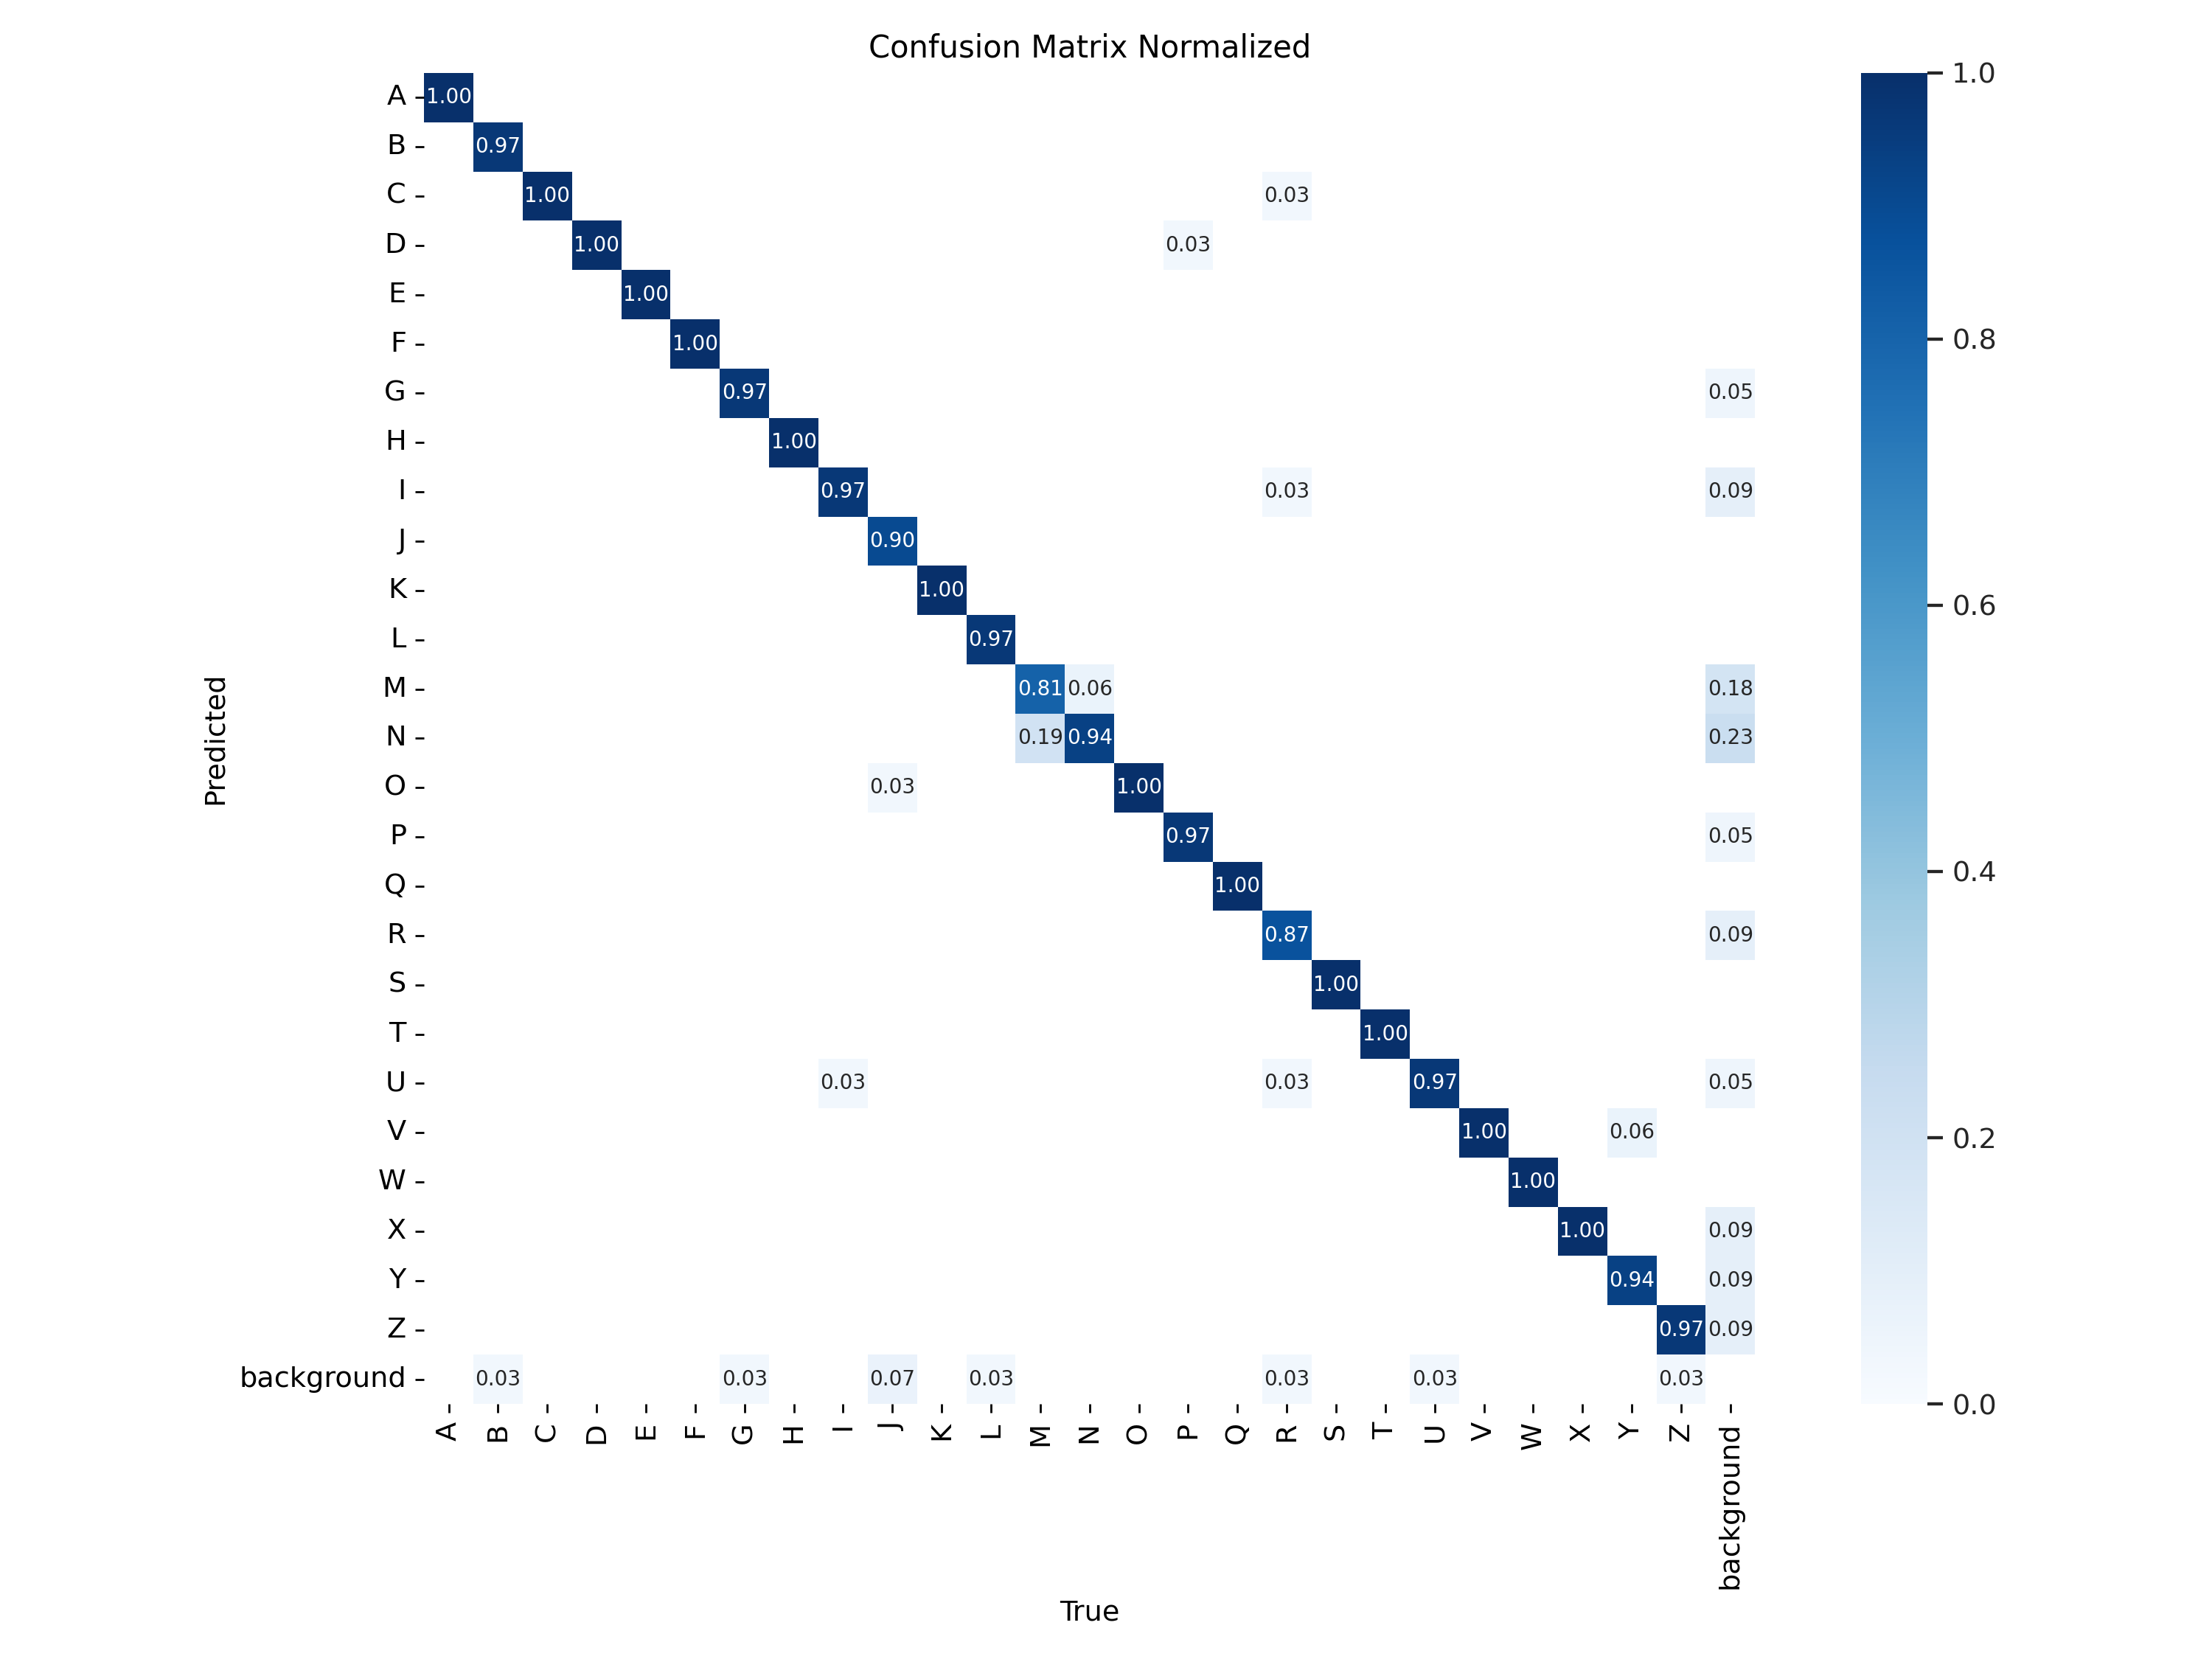


--- Results — Small ---


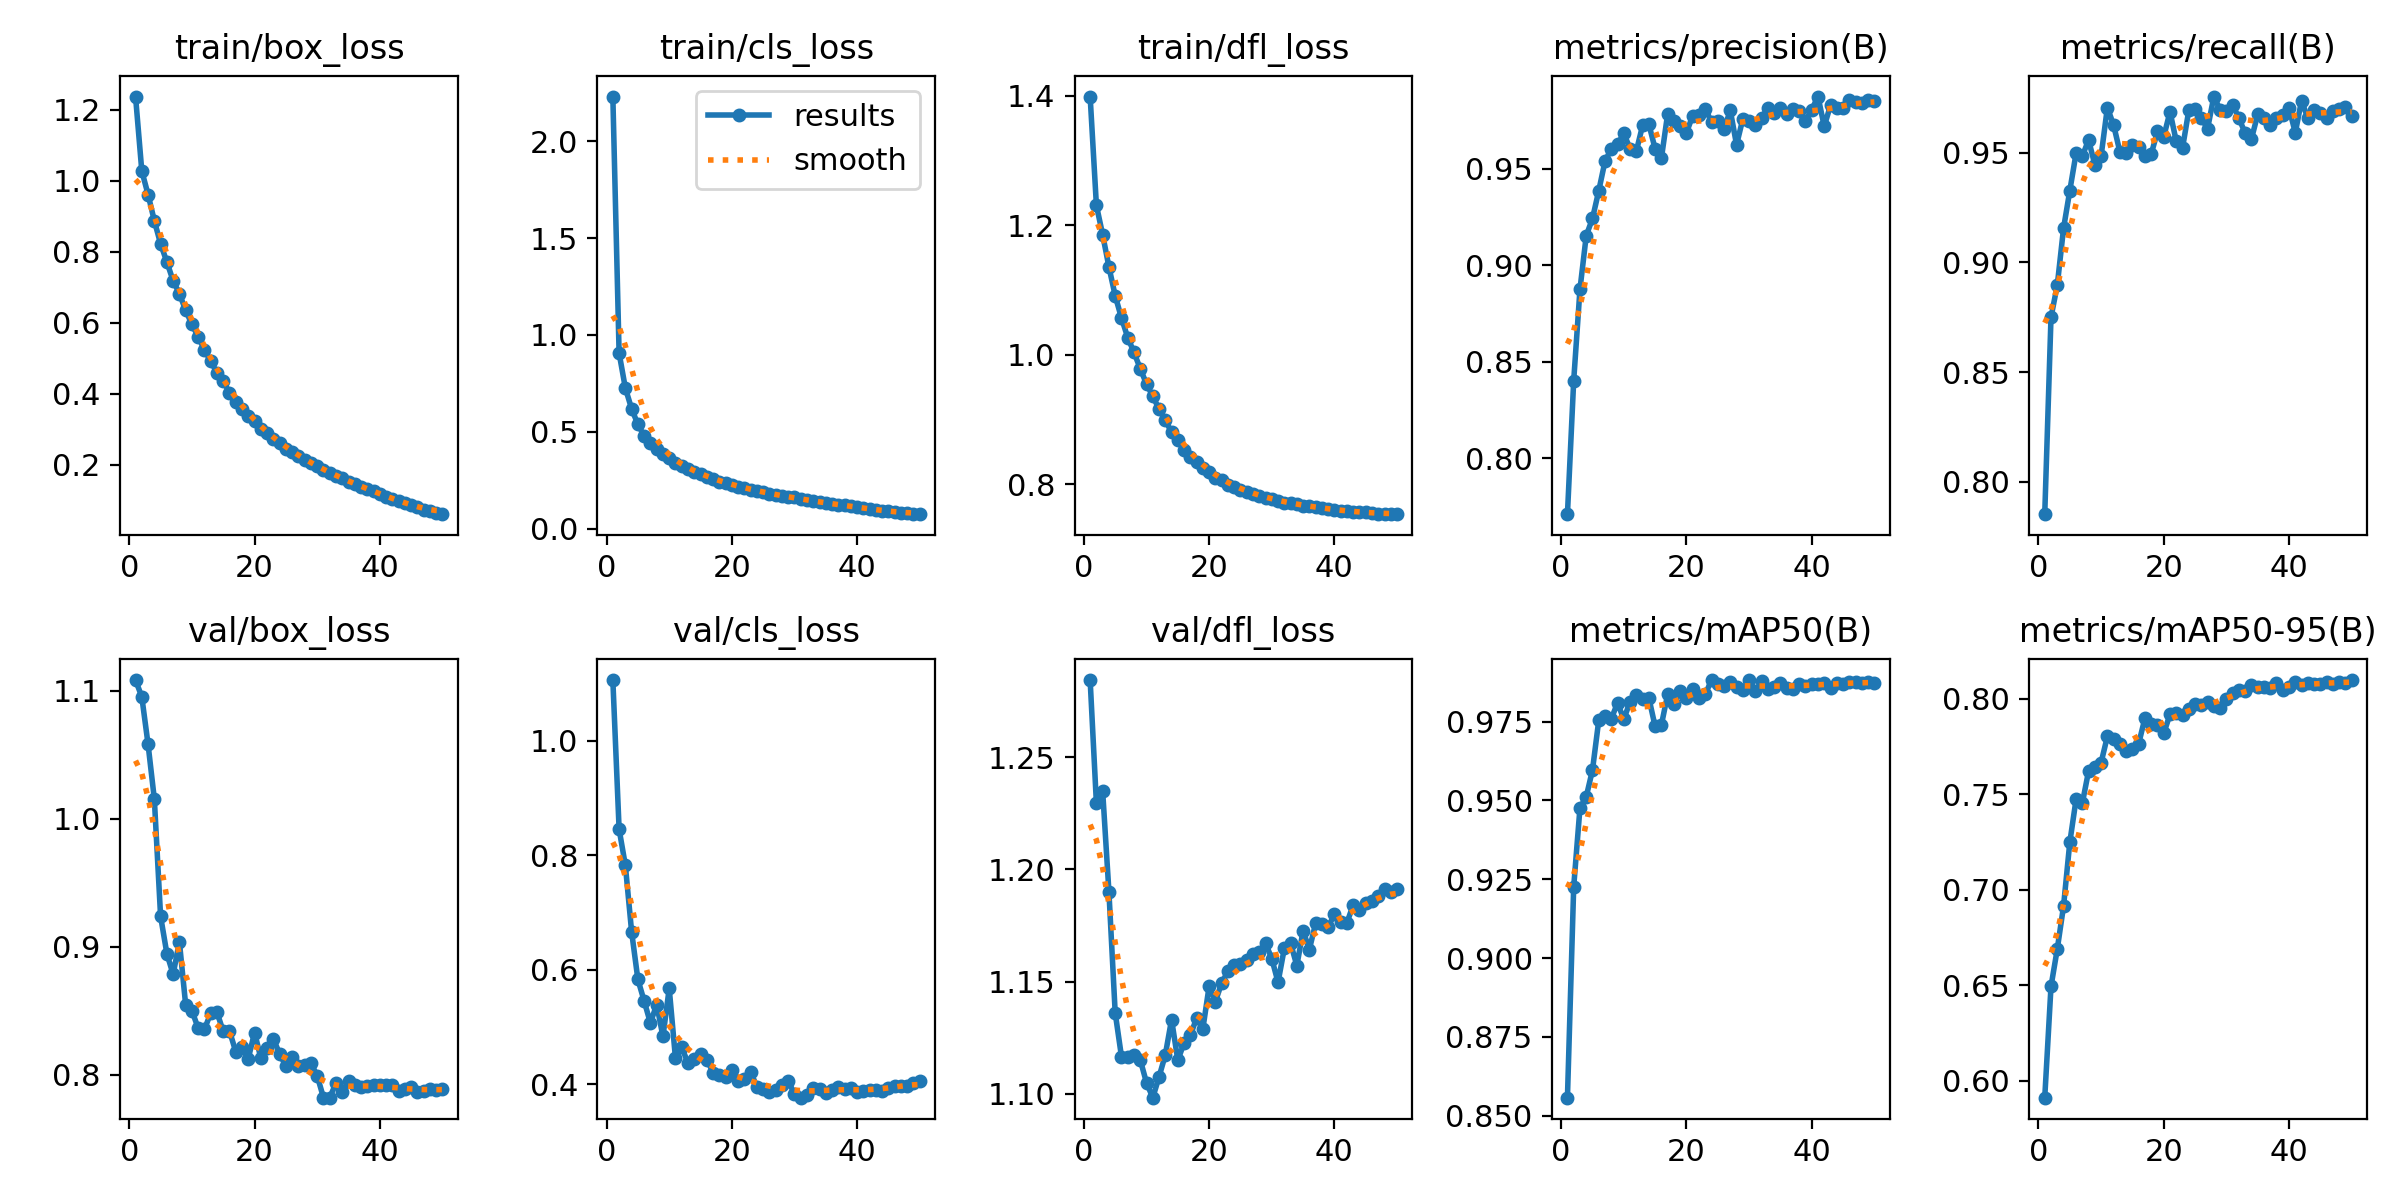

In [47]:
# ============================================================
# SEL 29 — Visualisasi Hasil Training — YOLOv11 Small
# confusion_matrix_normalized.png, results.png
# ============================================================
gambar_small = [
    ('confusion_matrix_normalized.png', 'Confusion Matrix (Normalized) — Small'),
    ('results.png',                     'Results — Small'),
]

for fname, judul in gambar_small:
    fpath = f'{TRAIN_DIR_SMALL}/{fname}'
    if os.path.exists(fpath):
        print(f'\n--- {judul} ---')
        display(IPyImage(filename=fpath, width=650))
    else:
        print(f'[!] File tidak ditemukan: {fpath}')


---
## BAGIAN 21 — Tabel Metrik Per Kelas — YOLOv11 Nano


In [48]:
# ============================================================
# SEL 30 — Tabel Metrik Per Kelas (Kelas, Precision, Recall, F1, mAP50, mAP50-95) — Nano
# ============================================================

def buat_tabel_per_kelas(res) -> pd.DataFrame:
    """Bangun DataFrame metrik per kelas dari satu hasil evaluasi Ultralytics."""
    p_pk, r_pk, ap50_pk, ap_pk = res.box.p, res.box.r, res.box.ap50, res.box.ap
    names_map = res.names
    rows = []
    for i, name in names_map.items():
        if i < len(p_pk):
            p, r = float(p_pk[i]), float(r_pk[i])
            f1 = 2 * p * r / (p + r + 1e-9)
            rows.append({'Kelas': name, 'Precision': round(p, 4), 'Recall': round(r, 4),
                         'F1': round(f1, 4), 'mAP50': round(float(ap50_pk[i]), 4),
                         'mAP50-95': round(float(ap_pk[i]), 4)})
    return pd.DataFrame(rows)

df_per_kelas_nano = buat_tabel_per_kelas(test_nano)

print('TABEL METRIK PER KELAS — YOLOv11 NANO')
print('=' * 55)
print(df_per_kelas_nano.to_string(index=False))

df_per_kelas_nano.to_csv(f'{HOME}/metrik_per_kelas_nano.csv', index=False)
print(f'\nTabel disimpan: metrik_per_kelas_nano.csv')


TABEL METRIK PER KELAS — YOLOv11 NANO
Kelas  Precision  Recall     F1  mAP50  mAP50-95
    A     1.0000  0.9333 0.9655 0.9665    0.7769
    B     1.0000  0.9032 0.9492 0.9515    0.7720
    C     1.0000  0.9032 0.9492 0.9515    0.7394
    D     1.0000  0.8710 0.9310 0.9355    0.7578
    E     1.0000  0.9032 0.9492 0.9515    0.7407
    F     1.0000  0.9000 0.9474 0.9500    0.6982
    G     1.0000  0.9355 0.9667 0.9675    0.8002
    H     1.0000  0.9355 0.9667 0.9675    0.8430
    I     1.0000  0.7097 0.8302 0.8548    0.6842
    J     1.0000  0.8065 0.8929 0.9032    0.7564
    K     1.0000  0.7742 0.8727 0.8870    0.6699
    L     1.0000  0.8710 0.9310 0.9355    0.7880
    M     0.8387  0.8387 0.8387 0.8422    0.6874
    N     0.9200  0.7667 0.8364 0.8597    0.7251
    O     1.0000  0.8065 0.8929 0.9032    0.7472
    P     1.0000  0.9032 0.9492 0.9515    0.7595
    Q     1.0000  0.7097 0.8302 0.8548    0.6718
    R     1.0000  0.8387 0.9123 0.9193    0.7611
    S     1.0000  0.9355 0.9667

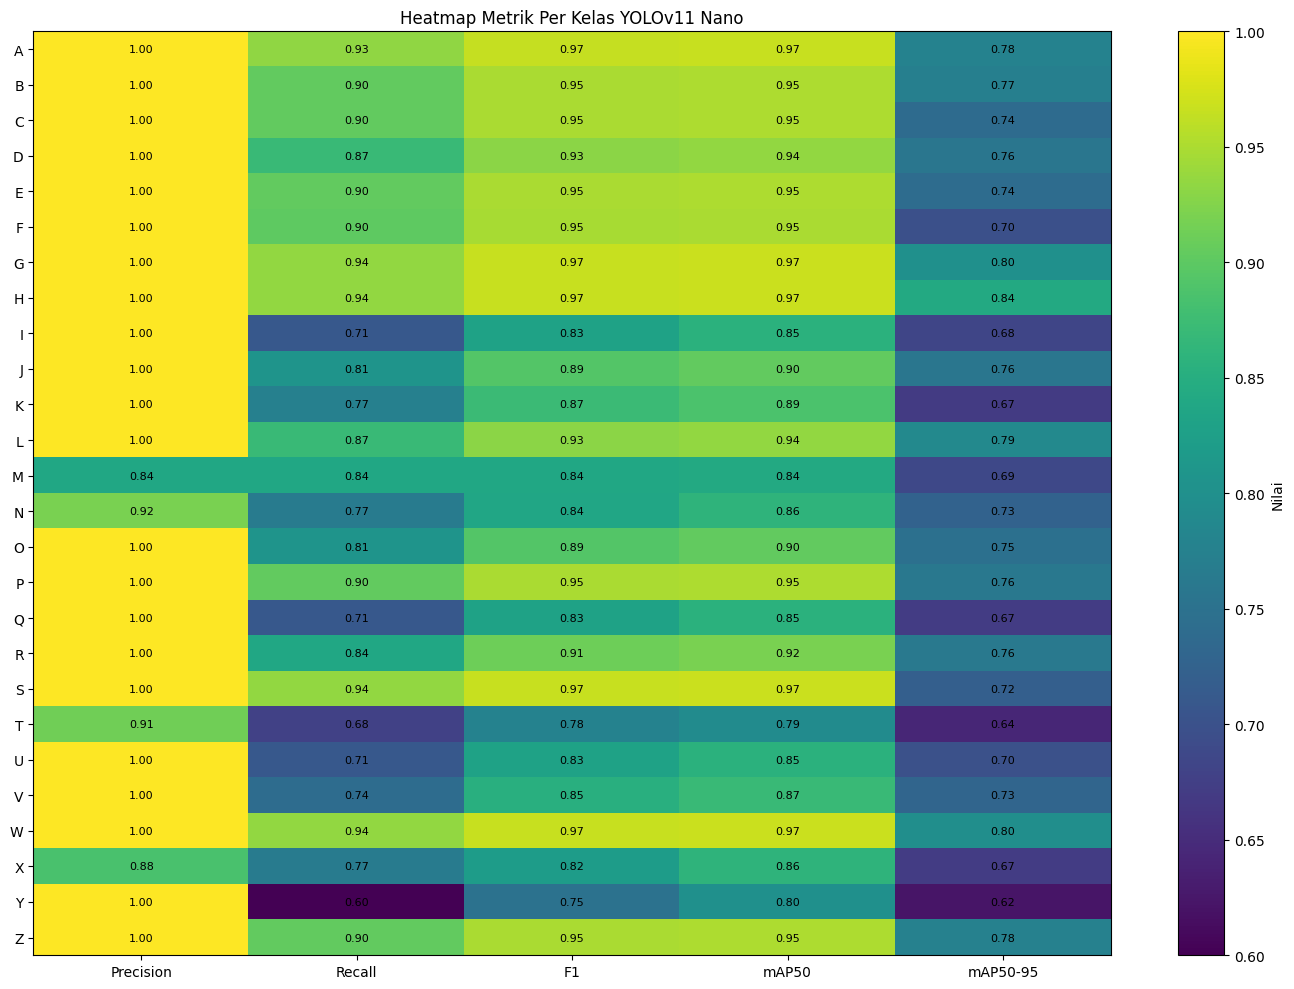

In [49]:
# ============================================================
# Heatmap Metrik Per Kelas
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

data = df_per_kelas_nano.set_index('Kelas')

plt.imshow(data.values, aspect='auto')

plt.colorbar(label='Nilai')

plt.xticks(range(len(data.columns)), data.columns)
plt.yticks(range(len(data.index)), data.index)

plt.title('Heatmap Metrik Per Kelas YOLOv11 Nano')

# Menampilkan nilai pada setiap sel
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        plt.text(j, i,
                 f"{data.iloc[i,j]:.2f}",
                 ha='center',
                 va='center',
                 fontsize=8,
                 color='white' if data.iloc[i,j] < 0.5 else 'black')

plt.tight_layout()

plt.savefig(f'{HOME}/heatmap_metrik_per_kelas_nano.png', dpi=300)
plt.show()

---
## BAGIAN 22 — Tabel Metrik Per Kelas — YOLOv11 Small


In [50]:
# ============================================================
# SEL 31 — Tabel Metrik Per Kelas (Kelas, Precision, Recall, F1, mAP50, mAP50-95) — Small
# ============================================================
df_per_kelas_small = buat_tabel_per_kelas(test_small)

print('TABEL METRIK PER KELAS — YOLOv11 SMALL')
print('=' * 55)
print(df_per_kelas_small.to_string(index=False))

df_per_kelas_small.to_csv(f'{HOME}/metrik_per_kelas_small.csv', index=False)
print(f'\nTabel disimpan: metrik_per_kelas_small.csv')


TABEL METRIK PER KELAS — YOLOv11 SMALL
Kelas  Precision  Recall     F1  mAP50  mAP50-95
    A     1.0000  0.9667 0.9831 0.9830    0.8259
    B     1.0000  0.9677 0.9836 0.9836    0.8254
    C     1.0000  0.9677 0.9836 0.9836    0.8284
    D     1.0000  1.0000 1.0000 0.9950    0.8380
    E     1.0000  0.9677 0.9836 0.9836    0.7661
    F     1.0000  0.9667 0.9831 0.9830    0.7502
    G     1.0000  1.0000 1.0000 0.9950    0.8515
    H     1.0000  1.0000 1.0000 0.9950    0.8683
    I     1.0000  0.9677 0.9836 0.9836    0.7864
    J     1.0000  0.9677 0.9836 0.9836    0.8312
    K     1.0000  1.0000 1.0000 0.9950    0.7592
    L     1.0000  0.9355 0.9667 0.9675    0.8348
    M     0.9333  0.9032 0.9180 0.9260    0.7814
    N     1.0000  0.9333 0.9655 0.9665    0.8365
    O     1.0000  0.9355 0.9667 0.9675    0.7882
    P     1.0000  0.9677 0.9836 0.9836    0.7825
    Q     1.0000  0.9677 0.9836 0.9836    0.7725
    R     1.0000  0.7742 0.8727 0.8870    0.7701
    S     1.0000  0.9677 0.983

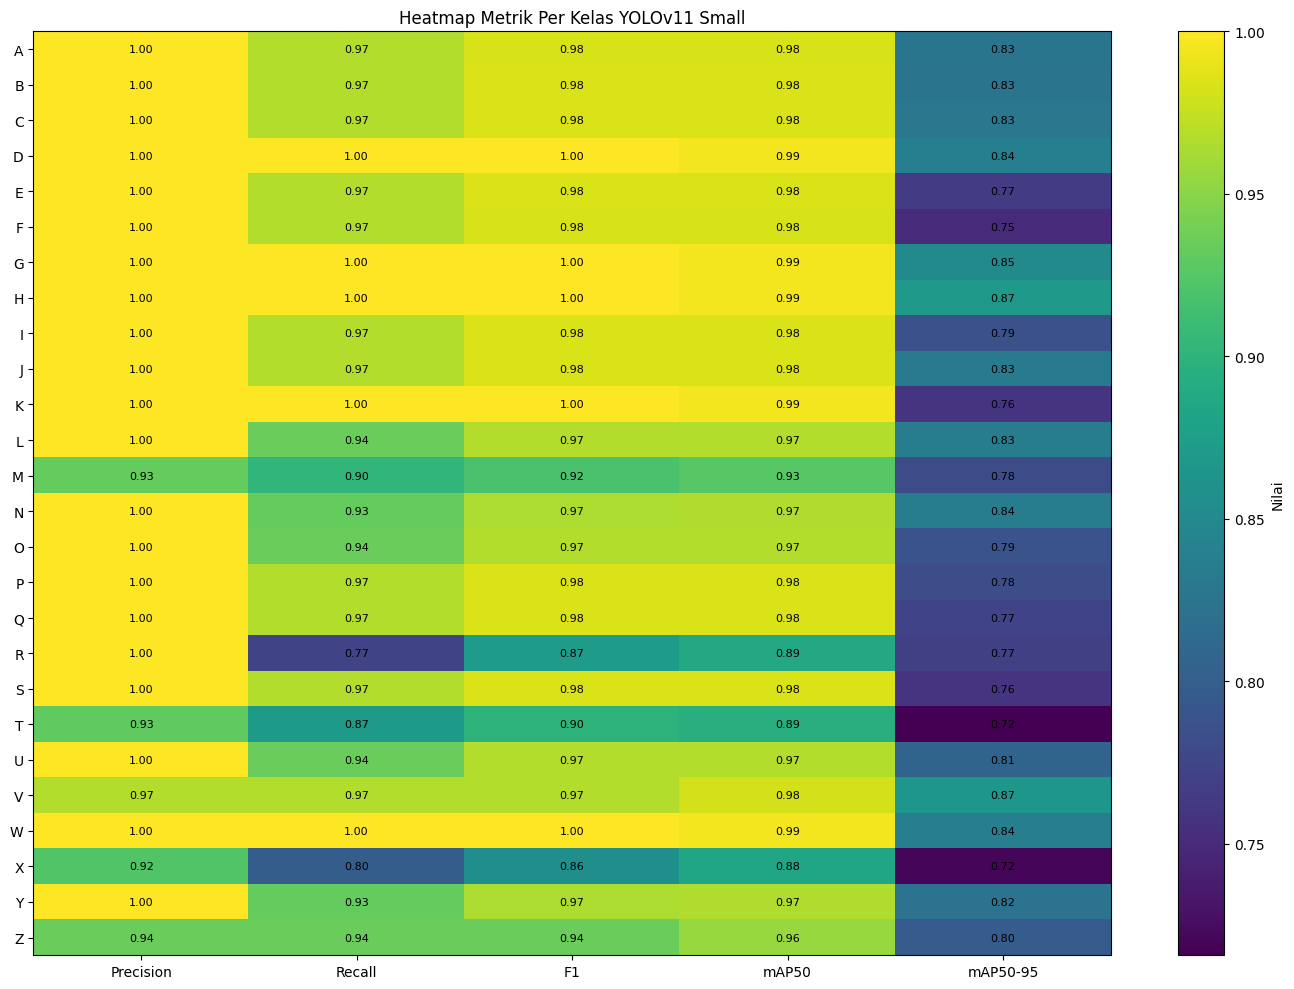

In [51]:
# ============================================================
# Heatmap Metrik Per Kelas
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

data = df_per_kelas_small.set_index('Kelas')

plt.imshow(data.values, aspect='auto')

plt.colorbar(label='Nilai')

plt.xticks(range(len(data.columns)), data.columns)
plt.yticks(range(len(data.index)), data.index)

plt.title('Heatmap Metrik Per Kelas YOLOv11 Small')

# Menampilkan nilai pada setiap sel
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        plt.text(j, i,
                 f"{data.iloc[i,j]:.2f}",
                 ha='center',
                 va='center',
                 fontsize=8,
                 color='white' if data.iloc[i,j] < 0.5 else 'black')

plt.tight_layout()

plt.savefig(f'{HOME}/heatmap_metrik_per_kelas_small.png', dpi=300)
plt.show()

---
## BAGIAN 23 — Pengukuran FPS — YOLOv11 Nano


In [52]:
# ============================================================
# SEL 32 — Pengukuran FPS & Waktu Inferensi — YOLOv11 Nano
# ============================================================
import time
import cv2

fps_img_dir = f'{MERGED_DIR}/test/images'
if not os.path.exists(fps_img_dir):
    fps_img_dir = f'{MERGED_DIR}/valid/images'

img_list_fps = [os.path.join(fps_img_dir, f)
                for f in os.listdir(fps_img_dir)
                if f.endswith(('.jpg', '.jpeg', '.png'))][:50]

# Warmup
for img_path in img_list_fps[:5]:
    frame = cv2.imread(img_path)
    _ = model_nano_eval.predict(frame, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)

times_nano = []
for img_path in img_list_fps:
    frame = cv2.imread(img_path)
    t0 = time.perf_counter()
    _ = model_nano_eval.predict(frame, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)
    times_nano.append(time.perf_counter() - t0)

AVG_MS_NANO  = float(np.mean(times_nano) * 1000)
AVG_FPS_NANO = float(1.0 / np.mean(times_nano))

print('PENGUKURAN KECEPATAN INFERENSI — YOLOv11 NANO')
print('=' * 50)
print(f'Jumlah sampel          : {len(img_list_fps)} gambar')
print(f'Rata-rata waktu proses : {AVG_MS_NANO:.2f} ms')
print(f'FPS rata-rata          : {AVG_FPS_NANO:.1f} FPS')
status = 'REAL-TIME' if AVG_FPS_NANO >= 24 else ('NEAR REAL-TIME' if AVG_FPS_NANO >= 10 else 'TIDAK REAL-TIME')
print(f'Status                 : {status}')


PENGUKURAN KECEPATAN INFERENSI — YOLOv11 NANO
Jumlah sampel          : 50 gambar
Rata-rata waktu proses : 11.91 ms
FPS rata-rata          : 84.0 FPS
Status                 : REAL-TIME


---
## BAGIAN 24 — Pengukuran FPS — YOLOv11 Small


In [53]:
# ============================================================
# SEL 33 — Pengukuran FPS & Waktu Inferensi — YOLOv11 Small
# ============================================================
# Warmup
for img_path in img_list_fps[:5]:
    frame = cv2.imread(img_path)
    _ = model_small_eval.predict(frame, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)

times_small = []
for img_path in img_list_fps:
    frame = cv2.imread(img_path)
    t0 = time.perf_counter()
    _ = model_small_eval.predict(frame, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)
    times_small.append(time.perf_counter() - t0)

AVG_MS_SMALL  = float(np.mean(times_small) * 1000)
AVG_FPS_SMALL = float(1.0 / np.mean(times_small))

print('PENGUKURAN KECEPATAN INFERENSI — YOLOv11 SMALL')
print('=' * 50)
print(f'Jumlah sampel          : {len(img_list_fps)} gambar')
print(f'Rata-rata waktu proses : {AVG_MS_SMALL:.2f} ms')
print(f'FPS rata-rata          : {AVG_FPS_SMALL:.1f} FPS')
status = 'REAL-TIME' if AVG_FPS_SMALL >= 24 else ('NEAR REAL-TIME' if AVG_FPS_SMALL >= 10 else 'TIDAK REAL-TIME')
print(f'Status                 : {status}')


PENGUKURAN KECEPATAN INFERENSI — YOLOv11 SMALL
Jumlah sampel          : 50 gambar
Rata-rata waktu proses : 11.70 ms
FPS rata-rata          : 85.4 FPS
Status                 : REAL-TIME


In [55]:
display(df_per_kelas_nano)
display(df_per_kelas_small)

,Kelas,Precision,Recall,F1,mAP50,mAP50-95
0,A,1.0000,0.9333,0.9655,0.9665,0.7769
1,B,1.0000,0.9032,0.9492,0.9515,0.7720
2,C,1.0000,0.9032,0.9492,0.9515,0.7394
3,D,1.0000,0.8710,0.9310,0.9355,0.7578
4,E,1.0000,0.9032,0.9492,0.9515,0.7407
5,F,1.0000,0.9000,0.9474,0.9500,0.6982
6,G,1.0000,0.9355,0.9667,0.9675,0.8002
7,H,1.0000,0.9355,0.9667,0.9675,0.8430
8,I,1.0000,0.7097,0.8302,0.8548,0.6842
9,J,1.0000,0.8065,0.8929,0.9032,0.7564


,Kelas,Precision,Recall,F1,mAP50,mAP50-95
0,A,1.0000,0.9667,0.9831,0.9830,0.8259
1,B,1.0000,0.9677,0.9836,0.9836,0.8254
2,C,1.0000,0.9677,0.9836,0.9836,0.8284
3,D,1.0000,1.0000,1.0000,0.9950,0.8380
4,E,1.0000,0.9677,0.9836,0.9836,0.7661
5,F,1.0000,0.9667,0.9831,0.9830,0.7502
6,G,1.0000,1.0000,1.0000,0.9950,0.8515
7,H,1.0000,1.0000,1.0000,0.9950,0.8683
8,I,1.0000,0.9677,0.9836,0.9836,0.7864
9,J,1.0000,0.9677,0.9836,0.9836,0.8312


In [54]:
# ============================================================
# SEL Membuat DataFrame Perbandingan Nano vs Small
# ============================================================

import pandas as pd

# Ambil rata-rata metrik dari seluruh kelas
nano = df_per_kelas_nano[['Precision','Recall','F1','mAP50','mAP50-95']].mean()
small = df_per_kelas_small[['Precision','Recall','F1','mAP50','mAP50-95']].mean()

df_perbandingan = pd.DataFrame({
    'Parameter': [
        'Precision',
        'Recall',
        'F1 Score',
        'mAP@50',
        'mAP@50-95',
        'FPS',
        'Inference Time (ms)'
    ],
    'Nano': [
        nano['Precision'],
        nano['Recall'],
        nano['F1'],
        nano['mAP50'],
        nano['mAP50-95'],
        AVG_FPS_NANO,
        AVG_MS_NANO
    ],
    'Small': [
        small['Precision'],
        small['Recall'],
        small['F1'],
        small['mAP50'],
        small['mAP50-95'],
        AVG_FPS_SMALL,
        AVG_MS_SMALL
    ]
})

display(df_perbandingan)

,Parameter,Nano,Small
0,Precision,0.982935,0.988100
1,Recall,0.829988,0.946142
2,F1 Score,0.897127,0.966042
3,mAP@50,0.908400,0.968177
4,mAP@50-95,0.732381,0.800904
5,FPS,83.975245,85.440330
6,Inference Time (ms),11.908271,11.704075


---
## BAGIAN 25 — Perbandingan YOLOv11 Nano vs YOLOv11 Small

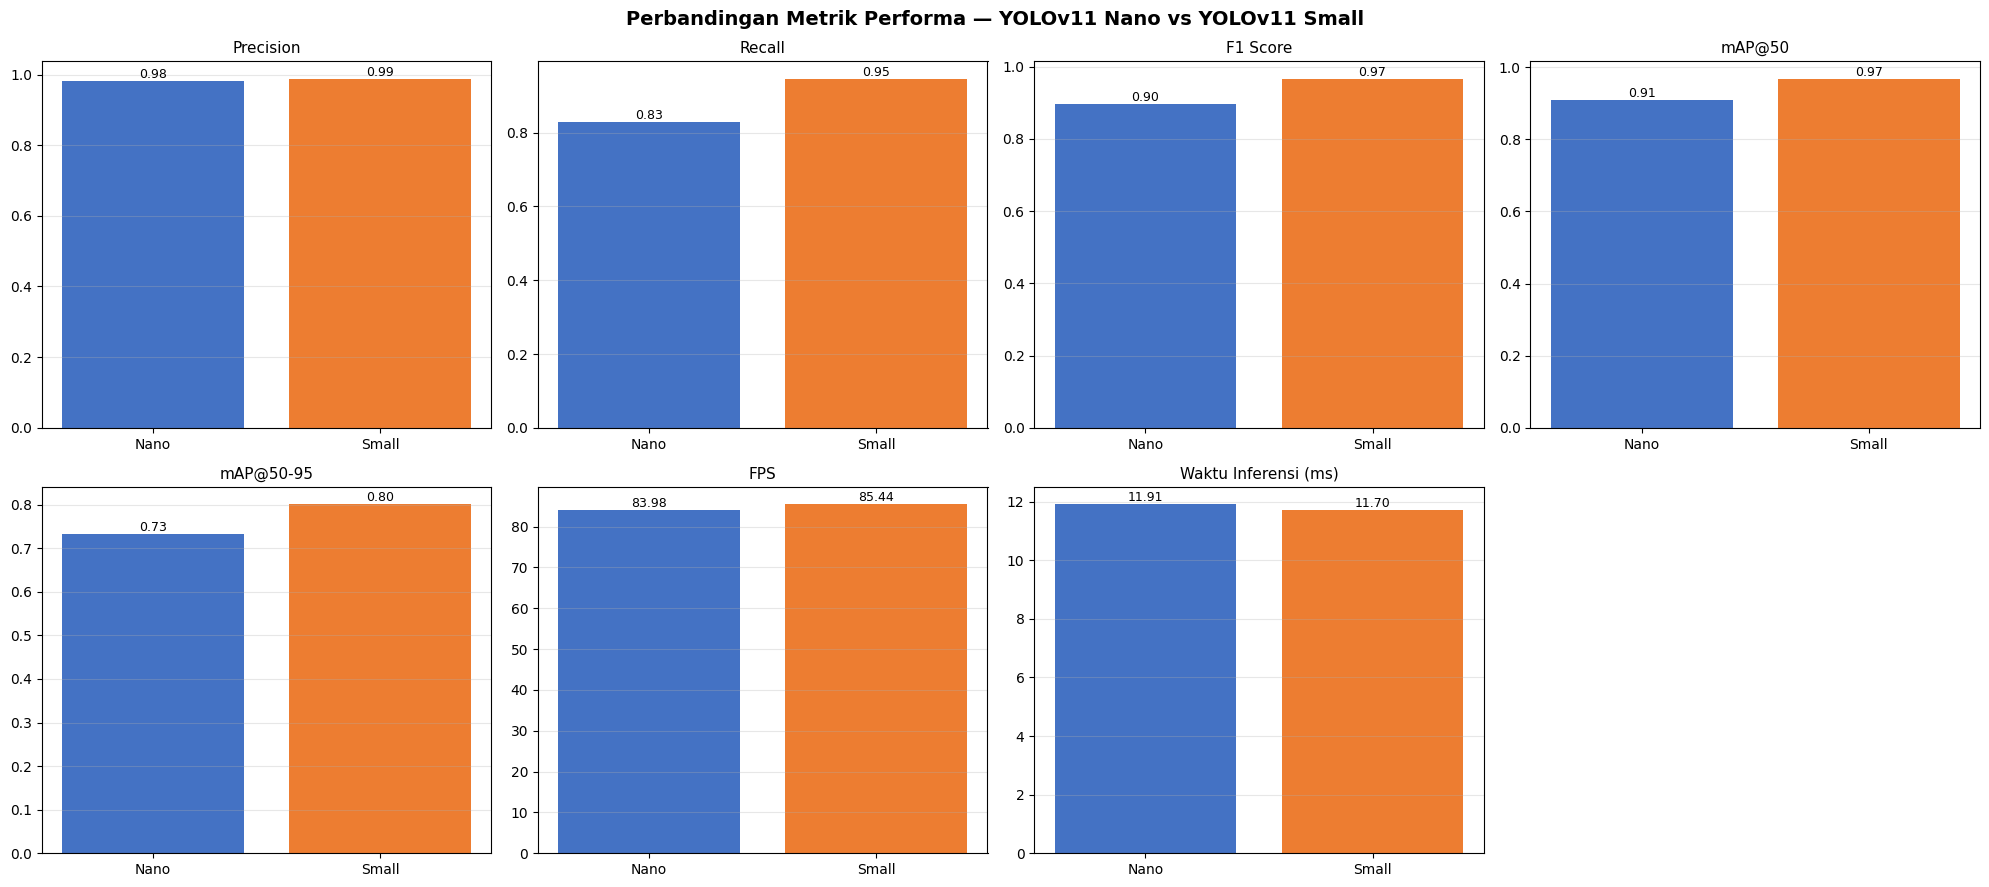

Grafik disimpan: grafik_perbandingan_nano_small.png


In [56]:
# ============================================================
# SEL 35 — Grafik Perbandingan YOLOv11 Nano vs YOLOv11 Small
# Precision, Recall, F1, mAP50, mAP50-95, FPS, Inference Time
# ============================================================
WARNA_MODEL = {'Nano': '#4472C4', 'Small': '#ED7D31'}

# Membuat DataFrame Perbandingan Nano vs Small
# Ambil rata-rata metrik dari seluruh kelas
nano = df_per_kelas_nano[['Precision','Recall','F1','mAP50','mAP50-95']].mean()
small = df_per_kelas_small[['Precision','Recall','F1','mAP50','mAP50-95']].mean()

df_perbandingan = pd.DataFrame({
    'Parameter': [
        'Precision',
        'Recall',
        'F1 Score',
        'mAP@50',
        'mAP@50-95',
        'FPS',
        'Inference Time (ms)'
    ],
    'Nano': [
        nano['Precision'],
        nano['Recall'],
        nano['F1'],
        nano['mAP50'],
        nano['mAP50-95'],
        AVG_FPS_NANO,
        AVG_MS_NANO
    ],
    'Small': [
        small['Precision'],
        small['Recall'],
        small['F1'],
        small['mAP50'],
        small['mAP50-95'],
        AVG_FPS_SMALL,
        AVG_MS_SMALL
    ]
})


metrik_grafik = [
    ('Precision',            'Precision'),
    ('Recall',               'Recall'),
    ('F1 Score',             'F1 Score'),
    ('mAP@50',               'mAP@50'),
    ('mAP@50-95',            'mAP@50-95'),
    ('FPS',                  'FPS'),
    ('Inference Time (ms)',  'Waktu Inferensi (ms)'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
fig.suptitle('Perbandingan Metrik Performa — YOLOv11 Nano vs YOLOv11 Small', fontsize=14, fontweight='bold')

for ax, (nama_param, judul) in zip(axes, metrik_grafik):
    nilai = [float(df_perbandingan.loc[df_perbandingan['Parameter'] == nama_param, m].values[0])
              for m in ['Nano', 'Small']]
    bars = ax.bar(['Nano', 'Small'], nilai, color=[WARNA_MODEL['Nano'], WARNA_MODEL['Small']])
    ax.set_title(judul, fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, nilai):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{v:.2f}',
                ha='center', va='bottom', fontsize=9)

for ax in axes[len(metrik_grafik):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{HOME}/grafik_perbandingan_nano_small.png', dpi=300, bbox_inches='tight')
plt.show()
print('Grafik disimpan: grafik_perbandingan_nano_small.png')


In [57]:
from pathlib import Path

SIZE_NANO = Path(BEST_NANO_PATH).stat().st_size / (1024 * 1024)
SIZE_SMALL = Path(BEST_SMALL_PATH).stat().st_size / (1024 * 1024)

print(f"Nano : {SIZE_NANO:.2f} MB")
print(f"Small: {SIZE_SMALL:.2f} MB")

Nano : 5.22 MB
Small: 18.31 MB


---
## BAGIAN 26 — Pemilihan Model Terbaik


In [58]:
# ============================================================
# SEL 36 — Pemilihan Model Terbaik
# Berdasarkan metrik utama Ultralytics (mAP@50-95)
# ============================================================

from pathlib import Path
from typing import List

# ============================================================
# Informasi Model
# ============================================================

SIZE_NANO = Path(BEST_NANO_PATH).stat().st_size / (1024 * 1024)
SIZE_SMALL = Path(BEST_SMALL_PATH).stat().st_size / (1024 * 1024)

MAP_NANO = test_nano.box.map          # mAP@50-95
MAP_SMALL = test_small.box.map

MAP50_NANO = test_nano.box.map50      # mAP@50
MAP50_SMALL = test_small.box.map50

# ============================================================
# Pemilihan Model Terbaik
# Acuan:
# - Ultralytics menggunakan mAP@50-95 sebagai metrik utama
#   evaluasi performa object detection.
# ============================================================

if MAP_NANO >= MAP_SMALL:
    MODEL_TERBAIK = "Nano"
    BEST_MODEL = model_nano_eval
    BEST_MODEL_PATH = BEST_NANO_PATH
else:
    MODEL_TERBAIK = "Small"
    BEST_MODEL = model_small_eval
    BEST_MODEL_PATH = BEST_SMALL_PATH

# ============================================================
# Ringkasan Perbandingan Metrik
# ============================================================

alasan: List[str] = [
    f"mAP@50-95  : {MAP_NANO:.4f} (Nano) vs {MAP_SMALL:.4f} (Small)",
    f"mAP@50     : {MAP50_NANO:.4f} (Nano) vs {MAP50_SMALL:.4f} (Small)",
    f"Precision  : {nano['Precision']:.4f} (Nano) vs {small['Precision']:.4f} (Small)",
    f"Recall     : {nano['Recall']:.4f} (Nano) vs {small['Recall']:.4f} (Small)",
    f"F1-Score   : {nano['F1']:.4f} (Nano) vs {small['F1']:.4f} (Small)",
    f"FPS        : {AVG_FPS_NANO:.2f} (Nano) vs {AVG_FPS_SMALL:.2f} (Small)",
    f"Model Size : {SIZE_NANO:.2f} MB (Nano) vs {SIZE_SMALL:.2f} MB (Small)",
]

# ============================================================
# Hasil Pemilihan Model
# ============================================================

print("=" * 60)
print("HASIL PEMILIHAN MODEL TERBAIK")
print("=" * 60)

print(f"Model Terbaik : YOLOv11 {MODEL_TERBAIK}")
print(f"Bobot Model   : {BEST_MODEL_PATH}")

print("\nRingkasan Metrik:")
for item in alasan:
    print(f"- {item}")

HASIL PEMILIHAN MODEL TERBAIK
Model Terbaik : YOLOv11 Small
Bobot Model   : /content/runs/detect/YOLOv11_Small/weights/best.pt

Ringkasan Metrik:
- mAP@50-95  : 0.7324 (Nano) vs 0.8009 (Small)
- mAP@50     : 0.9084 (Nano) vs 0.9682 (Small)
- Precision  : 0.9829 (Nano) vs 0.9881 (Small)
- Recall     : 0.8300 (Nano) vs 0.9461 (Small)
- F1-Score   : 0.8971 (Nano) vs 0.9660 (Small)
- FPS        : 83.98 (Nano) vs 85.44 (Small)
- Model Size : 5.22 MB (Nano) vs 18.31 MB (Small)


---
## BAGIAN 27 — Inferensi pada Gambar Test & Visualisasi Deteksi — Model Terbaik


Kelas ditemukan : 26 / 26


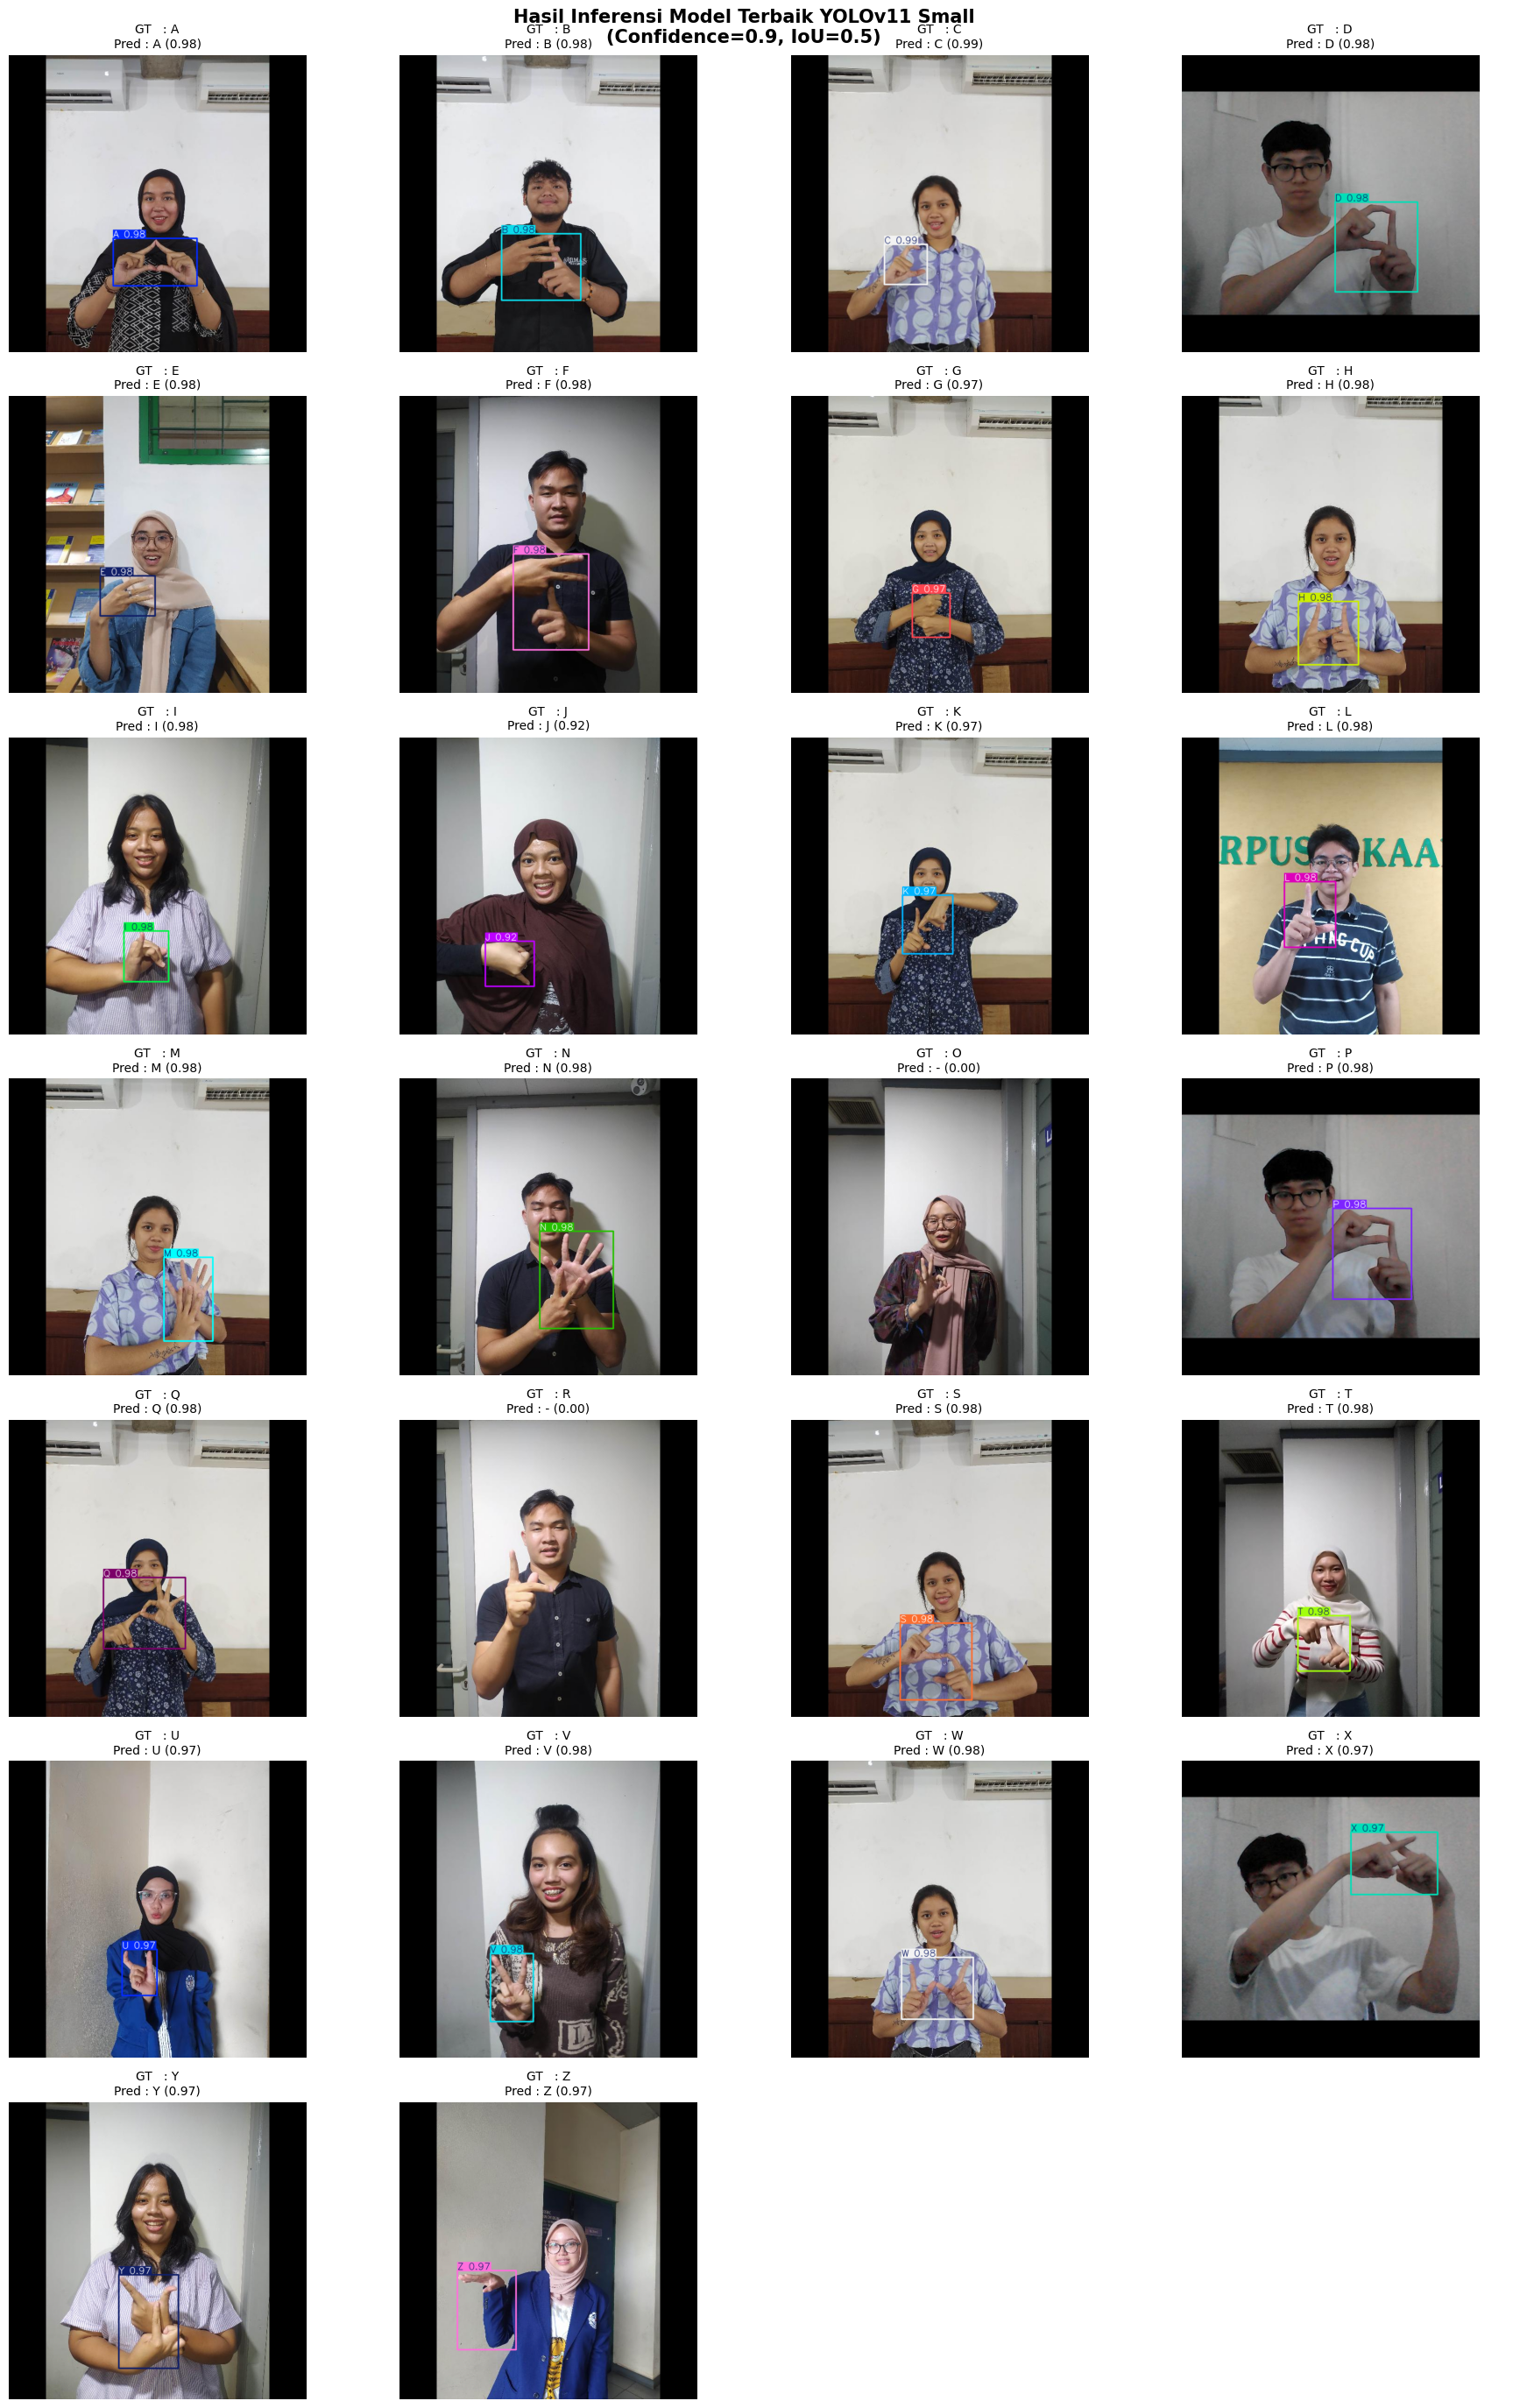

Gambar berhasil disimpan:
/content/hasil_inferensi_A_Z_model_terbaik.png


In [65]:
# ============================================================
# SEL 37 — Inferensi & Visualisasi Deteksi Menggunakan Model Terbaik
# Menampilkan satu sampel gambar untuk setiap kelas alfabet BISINDO
# ============================================================

import os
import cv2
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Tentukan folder gambar dan label
# ------------------------------------------------------------
vis_img_dir = os.path.join(MERGED_DIR, "test/images")
vis_lbl_dir = os.path.join(MERGED_DIR, "test/labels")

if not os.path.exists(vis_img_dir):
    vis_img_dir = os.path.join(MERGED_DIR, "valid/images")
    vis_lbl_dir = os.path.join(MERGED_DIR, "valid/labels")

# ------------------------------------------------------------
# Ambil satu sampel gambar untuk setiap kelas (A–Z)
# ------------------------------------------------------------
sample_per_class = {}

for img_name in sorted(os.listdir(vis_img_dir)):

    if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    label_path = os.path.join(
        vis_lbl_dir,
        os.path.splitext(img_name)[0] + ".txt"
    )

    if not os.path.exists(label_path):
        continue

    with open(label_path, "r") as f:
        lines = f.readlines()

    if not lines:
        continue

    class_id = int(lines[0].split()[0])

    if class_id not in sample_per_class:
        sample_per_class[class_id] = img_name

# ------------------------------------------------------------
# Urutkan berdasarkan kelas A–Z
# ------------------------------------------------------------
samples = [
    (class_id, sample_per_class[class_id])
    for class_id in sorted(sample_per_class.keys())
]

print(f"Kelas ditemukan : {len(samples)} / {len(CANONICAL_CLASSES)}")

# ------------------------------------------------------------
# Visualisasi
# ------------------------------------------------------------
cols = 4
rows = (len(samples) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

fig.suptitle(
    f"Hasil Inferensi Model Terbaik YOLOv11 {MODEL_TERBAIK}\n"
    f"(Confidence={CONF_THRESHOLD}, IoU={IOU_THRESHOLD})",
    fontsize=15,
    fontweight="bold"
)

# ------------------------------------------------------------
# Inferensi setiap gambar
# ------------------------------------------------------------
for ax, (class_id, img_name) in zip(axes, samples):

    img_path = os.path.join(vis_img_dir, img_name)

    image = cv2.imread(img_path)

    result = BEST_MODEL.predict(
        source=image,
        conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD,
        verbose=False
    )[0]

    annotated = result.plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    if len(result.boxes) > 0:
        pred_class = int(result.boxes.cls[0])
        pred_label = BEST_MODEL.names[pred_class]
        confidence = float(result.boxes.conf[0])
    else:
        pred_label = "-"
        confidence = 0.0

    ax.imshow(annotated)
    ax.set_title(
        f"GT   : {CANONICAL_CLASSES[class_id]}\n"
        f"Pred : {pred_label} ({confidence:.2f})",
        fontsize=10
    )
    ax.axis("off")

# ------------------------------------------------------------
# Sembunyikan subplot kosong
# ------------------------------------------------------------
for ax in axes[len(samples):]:
    ax.axis("off")

plt.tight_layout()

output_path = os.path.join(HOME, "hasil_inferensi_A_Z_model_terbaik.png")

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gambar berhasil disimpan:\n{output_path}")

---
## BAGIAN 28 — Ekspor Model Terbaik untuk Implementasi Real-Time


In [61]:
# ============================================================
# SEL 38 — Salin Bobot Model Terbaik ke Lokasi Tetap untuk Aplikasi Real-Time
# ============================================================
import shutil

REALTIME_MODEL_DIR = f'{HOME}/model_realtime'
os.makedirs(REALTIME_MODEL_DIR, exist_ok=True)
REALTIME_MODEL_PATH = f'{REALTIME_MODEL_DIR}/best_YOLOv11_{MODEL_TERBAIK}.pt'
shutil.copy2(BEST_MODEL_PATH, REALTIME_MODEL_PATH)

print(f'Model terbaik (YOLOv11 {MODEL_TERBAIK}) disalin ke:')
print(f'  {REALTIME_MODEL_PATH}')
print(f'\nKonfigurasi yang harus dipakai di aplikasi Streamlit (bisindo_suara.py):')
print(f'  MODEL_PATH        = "{os.path.basename(REALTIME_MODEL_PATH)}"')
print(f'  CONFIDENCE_THRESH = {CONF_THRESHOLD}')
print(f'  IOU_THRESHOLD     = {IOU_THRESHOLD}')


Model terbaik (YOLOv11 Small) disalin ke:
  /content/model_realtime/best_YOLOv11_Small.pt

Konfigurasi yang harus dipakai di aplikasi Streamlit (bisindo_suara.py):
  MODEL_PATH        = "best_YOLOv11_Small.pt"
  CONFIDENCE_THRESH = 0.9
  IOU_THRESHOLD     = 0.5


---
## BAGIAN 29 — Tabel Ringkasan Akhir


In [62]:
# ============================================================
# SEL 39 — Tabel Ringkasan Akhir Penelitian
# ============================================================
ringkasan_akhir = [
    ['Dataset', f'BISINDO Multi-Sumber ({len(SOURCE_DATASETS)} dataset Roboflow digabung, dedup, undersampling, split 80:10:10)'],
    ['Jumlah Kelas', f'{NC} kelas (A–Z)'],
    ['Jumlah Data Train', f'{split_counts.get("train", "-")} gambar'],
    ['Jumlah Data Valid', f'{split_counts.get("valid", "-")} gambar'],
    ['Jumlah Data Test', f'{split_counts.get("test", "-")} gambar'],
    ['Ukuran Gambar', '640 × 640 px'],
    ['Model Dibandingkan', 'YOLOv11 Nano, YOLOv11 Small'],
    ['Epoch', '50'],
    ['Batch Size', '16'],
    ['Optimizer', 'AdamW'],
    ['Learning Rate', '0.0003'],
    ['Augmentasi Training', 'Tidak ada (seluruh augmentasi dinonaktifkan)'],
    ['Confidence Threshold', f'{CONF_THRESHOLD}'],
    ['IoU Threshold', f'{IOU_THRESHOLD}'],
    ['--- MODEL TERBAIK (OTOMATIS) ---', ''],
    ['Model Terpilih', f'YOLOv11 {MODEL_TERBAIK}'],
    ['Alasan Utama', alasan[0] if alasan else '-'],
    ['Bobot Model Terbaik', REALTIME_MODEL_PATH],
]

df_ringkasan_akhir = pd.DataFrame(ringkasan_akhir, columns=['Parameter', 'Nilai'])
print('TABEL RINGKASAN AKHIR PENELITIAN')
print('Analisis Performa Model YOLOv11 untuk Deteksi BISINDO Berbasis Real-Time')
print('=' * 70)
print(df_ringkasan_akhir.to_string(index=False))

df_ringkasan_akhir.to_csv(f'{HOME}/ringkasan_akhir_penelitian.csv', index=False)
print(f'\nTabel disimpan: ringkasan_akhir_penelitian.csv')


TABEL RINGKASAN AKHIR PENELITIAN
Analisis Performa Model YOLOv11 untuk Deteksi BISINDO Berbasis Real-Time
                       Parameter                                                                                     Nilai
                         Dataset BISINDO Multi-Sumber (10 dataset Roboflow digabung, dedup, undersampling, split 80:10:10)
                    Jumlah Kelas                                                                            26 kelas (A–Z)
               Jumlah Data Train                                                                               6406 gambar
               Jumlah Data Valid                                                                                801 gambar
                Jumlah Data Test                                                                                801 gambar
                   Ukuran Gambar                                                                              640 × 640 px
              Model Dibandingkan 

---
## BAGIAN 30 — Ekspor Semua File


In [63]:
# ============================================================
# SEL 40 — Daftar Semua File yang Dihasilkan
# ============================================================
FILES_SKRIPSI = [
    (f'{HOME}/ringkasan_pipeline_dataset.csv',     'Bab I/III — Ringkasan pipeline penggabungan dataset'),
    (f'{HOME}/ringkasan_deduplikasi.csv',          'Bab III — Tabel ringkasan deduplikasi per dataset'),
    (f'{HOME}/distribusi_tiap_tahap_pipeline.png', 'Bab III — Distribusi kelas tiap tahap'),
    (f'{HOME}/validasi_keseimbangan_split.csv',    'Bab III — Tabel validasi keseimbangan split'),
    (f'{HOME}/validasi_keseimbangan_split.png',    'Bab III — Grafik validasi keseimbangan split'),
    (f'{HOME}/distribusi_dataset_bisindo.png',     'Bab III — Distribusi dataset final per kelas'),
    (f'{HOME}/contoh_dataset_train.png',           'Bab III — Contoh gambar dataset + anotasi'),
    (f'{HOME}/metrik_per_kelas_nano.csv',          'Bab IV  — Tabel metrik per kelas Nano'),
    (f'{HOME}/metrik_per_kelas_small.csv',         'Bab IV  — Tabel metrik per kelas Small'),
    (f'{HOME}/tabel_perbandingan_nano_small.csv',  'Bab IV  — Tabel perbandingan Nano vs Small'),
    (f'{HOME}/grafik_perbandingan_nano_small.png', 'Bab IV  — Grafik perbandingan Nano vs Small'),
    (f'{HOME}/hasil_deteksi_model_terbaik.png',    'Bab IV  — Contoh hasil deteksi model terbaik'),
    (f'{HOME}/ringkasan_akhir_penelitian.csv',     'Bab IV  — Tabel ringkasan akhir'),
    (BEST_NANO_PATH,                               'Model   — best.pt YOLOv11 Nano'),
    (BEST_SMALL_PATH,                              'Model   — best.pt YOLOv11 Small'),
    (REALTIME_MODEL_PATH,                          'Model   — bobot model terbaik untuk aplikasi real-time'),
]

print('DAFTAR FILE YANG DIHASILKAN UNTUK SKRIPSI')
print('=' * 70)
all_ok = True
for fpath, keterangan in FILES_SKRIPSI:
    exists = os.path.exists(fpath)
    status = '✓' if exists else '✗ TIDAK ADA'
    size   = f'({os.path.getsize(fpath)/1024:.0f} KB)' if exists else ''
    print(f'  [{status}] {os.path.basename(fpath):<45} {size}')
    print(f'         → {keterangan}')
    if not exists:
        all_ok = False

print()
if all_ok:
    print('Semua file berhasil dibuat. Siap untuk skripsi!')
else:
    print('[!] Beberapa file belum ada. Jalankan ulang sel yang kurang.')


DAFTAR FILE YANG DIHASILKAN UNTUK SKRIPSI
  [✓] ringkasan_pipeline_dataset.csv                (1 KB)
         → Bab I/III — Ringkasan pipeline penggabungan dataset
  [✓] ringkasan_deduplikasi.csv                     (0 KB)
         → Bab III — Tabel ringkasan deduplikasi per dataset
  [✓] distribusi_tiap_tahap_pipeline.png            (225 KB)
         → Bab III — Distribusi kelas tiap tahap
  [✓] validasi_keseimbangan_split.csv               (1 KB)
         → Bab III — Tabel validasi keseimbangan split
  [✓] validasi_keseimbangan_split.png               (168 KB)
         → Bab III — Grafik validasi keseimbangan split
  [✓] distribusi_dataset_bisindo.png                (166 KB)
         → Bab III — Distribusi dataset final per kelas
  [✓] contoh_dataset_train.png                      (1994 KB)
         → Bab III — Contoh gambar dataset + anotasi
  [✓] metrik_per_kelas_nano.csv                     (1 KB)
         → Bab IV  — Tabel metrik per kelas Nano
  [✓] metrik_per_kelas_small.csv   

In [64]:
# ============================================================
# SEL 41 — Download Semua File Sekaligus (Google Colab)
# ============================================================
import zipfile
from google.colab import files

ZIP_PATH = f'{HOME}/hasil_skripsi_bisindo_yolov11_nano_small.zip'

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fpath, _ in FILES_SKRIPSI:
        if os.path.exists(fpath):
            zf.write(fpath, os.path.basename(fpath))
            print(f'  + {os.path.basename(fpath)}')

zip_size = os.path.getsize(ZIP_PATH) / 1024 / 1024
print(f'\nZIP dibuat: {ZIP_PATH} ({zip_size:.1f} MB)')
print('Mendownload file ZIP...')
files.download(ZIP_PATH)


  + ringkasan_pipeline_dataset.csv
  + ringkasan_deduplikasi.csv
  + distribusi_tiap_tahap_pipeline.png
  + validasi_keseimbangan_split.csv
  + validasi_keseimbangan_split.png
  + distribusi_dataset_bisindo.png
  + contoh_dataset_train.png
  + metrik_per_kelas_nano.csv
  + metrik_per_kelas_small.csv
  + grafik_perbandingan_nano_small.png
  + hasil_deteksi_model_terbaik.png
  + ringkasan_akhir_penelitian.csv
  + best.pt
  + best.pt
  + best_YOLOv11_Small.pt

ZIP dibuat: /content/hasil_skripsi_bisindo_yolov11_nano_small.zip (44.0 MB)
Mendownload file ZIP...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Ringkasan Notebook

| Bagian | Sel | Output untuk Skripsi |
|--------|-----|----------------------|
| Setup & GPU | 1–3 | Spesifikasi hardware (Bab III) |
| Konfigurasi path/split/kelas | 4 | Rasio split, kelas kanonik |
| Download multi-sumber | 5–6 | Daftar & lokasi dataset sumber (Bab I/III) |
| Validasi & pemetaan kelas | 7–9 | Jaminan konsistensi kelas antar dataset |
| Gabung jadi satu pool | 10 | Komposisi awal per dataset sumber |
| Deteksi & hapus duplikat | 11–12 | Tabel dedup per dataset (Bab III) |
| Undersampling | 13 | Distribusi seimbang per kelas (Bab III) |
| Visualisasi tiap tahap | 14 | Grafik distribusi 3-tahap (Bab III) |
| Stratified split 80:10:10 | 15 | Jumlah train/valid/test final (Bab III) |
| Validasi keseimbangan split | 16 | Tabel & grafik validasi (Bab III) |
| Simpan dataset final | 17–18 | dataset_final/ + data.yaml |
| Ringkasan pipeline dataset | 19 | Tabel ringkasan (Bab I/III) |
| Verifikasi & analisis dataset final | 20–22 | Tabel distribusi + contoh gambar (Bab III) |
| Konfigurasi bersama training | 23 | Hyperparameter (Bab III) |
| **Training Nano** | 24 | Log training Nano |
| **Training Small** | 25 | Log training Small |
| **Validation & Test Nano** | 26 | Output Ultralytics lengkap — Nano (Bab IV) |
| **Validation & Test Small** | 27 | Output Ultralytics lengkap — Small (Bab IV) |
| **Confusion Matrix/Results Nano** | 28 | 4 gambar — Nano (Bab IV) |
| **Confusion Matrix/Results Small** | 29 | 4 gambar — Small (Bab IV) |
| **Tabel per kelas Nano** | 30 | CSV — Nano (Bab IV) |
| **Tabel per kelas Small** | 31 | CSV — Small (Bab IV) |
| **FPS Nano** | 32 | Kecepatan inferensi Nano (Bab IV) |
| **FPS Small** | 33 | Kecepatan inferensi Small (Bab IV) |
| **Perbandingan Nano vs Small** | 34–35 | **Tabel + grafik perbandingan (Bab IV)** |
| Pemilihan model terbaik (otomatis) | 36 | Kesimpulan model terpilih + alasan (Bab IV/V) |
| Inferensi — model terbaik | 37 | Contoh gambar hasil deteksi (Bab IV) |
| Ekspor model terbaik untuk real-time | 38 | Bobot + konfigurasi untuk `bisindo_suara.py` |
| Tabel ringkasan akhir | 39 | Tabel ringkasan gabungan (Bab IV) |
| Ekspor | 40–41 | ZIP semua file untuk skripsi |

